<h2 style="text-align: center;">НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ 
<br/>МОСКОВСКИЙ ЭНЕРГЕТИЧЕСКИЙ ИНСТИТУТ</h2>
</br>
<h3 style="text-align: center;">Кафедра Паровых и Газовых Турбин</h3>

</br>
</br>
</br>
</br>
</br>

<h1 style="text-align: center;">Курсовая работа по курсу:</h1>
<h1 style="text-align: center;">«Паровые и газовые турбины»</h1>

</br>
<h1 style="text-align: center;">Вариант 9</h2>
</br>
</br>
</br>
</br>

<h5 style="text-align: right;">Студент: Смирнов Сергей Артёмович</h5>
<h5 style="text-align: right;">Группа: ФПэ-01-22</h5>

</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: center;">Москва 2025</h5>

## Вариант №9

### $\space$ Дано:
* $P_0 = 23.4 \space МПа $ - Давление перед турбиной
* $t_0 = 545 ^\circ C$ -  Температура перед турбиной
* $P_{пп} = 3.3 \space МПа$ -  Давление промперегрева
* $t_{пп} = 545 ^\circ C$ -  Температура промперегрева
* $P_{к} = 5 \space кПа$ -  Давление в конденсаторе
* $t_{п.в.} = 263^\circ C$ -  Температура питательной воды

* $N_{э} = 320 \space МВт$ -  Электрическая мощность
* z = 9 -  Количество перегревателей

In [96]:
from mass_flow_class import mass_flow_class as mfc
from new_control_stage import MyClass as cst
from steam import Steam as sgas
import numpy as np

In [97]:
MPa = 10 ** 6
kPa = 10 ** 3
unit = 1 / MPa
to_kelvin = lambda x: x + 273.15 if x else None

In [98]:
p0 = 23.4 * MPa
my_class = sgas(name = "Пар", R = 461, c_p =287.05)

In [99]:
A = mfc(my_class,
        p0 = 23.4 * MPa ,
                   t0 = 545 ,
                   p_middle = 3.3 * MPa ,
                   t_middle = 545 ,
                   pk = 5 * kPa, 
                   t_feed_water = 263,
                   p_feed_water = 1.35 * p0*unit,

                   electrical_power = 320*10**6,
                   internal_efficiency = 0.85,
                   mechanical_efficiency = 0.995,
                   generator_efficiency = 0.99,
                   alpha = 0.83)
inlet_mass_flow = A.inlet_mass_flow
condenser_mass_flow = A.condenser_mass_flow
print("Расход на входе в турбину: ",round(inlet_mass_flow), "кг /с")
print("Расход на входе в конденсатор: ",round(condenser_mass_flow), "кг/с")

Расход на входе в турбину:  255 кг /с
Расход на входе в конденсатор:  174 кг/с


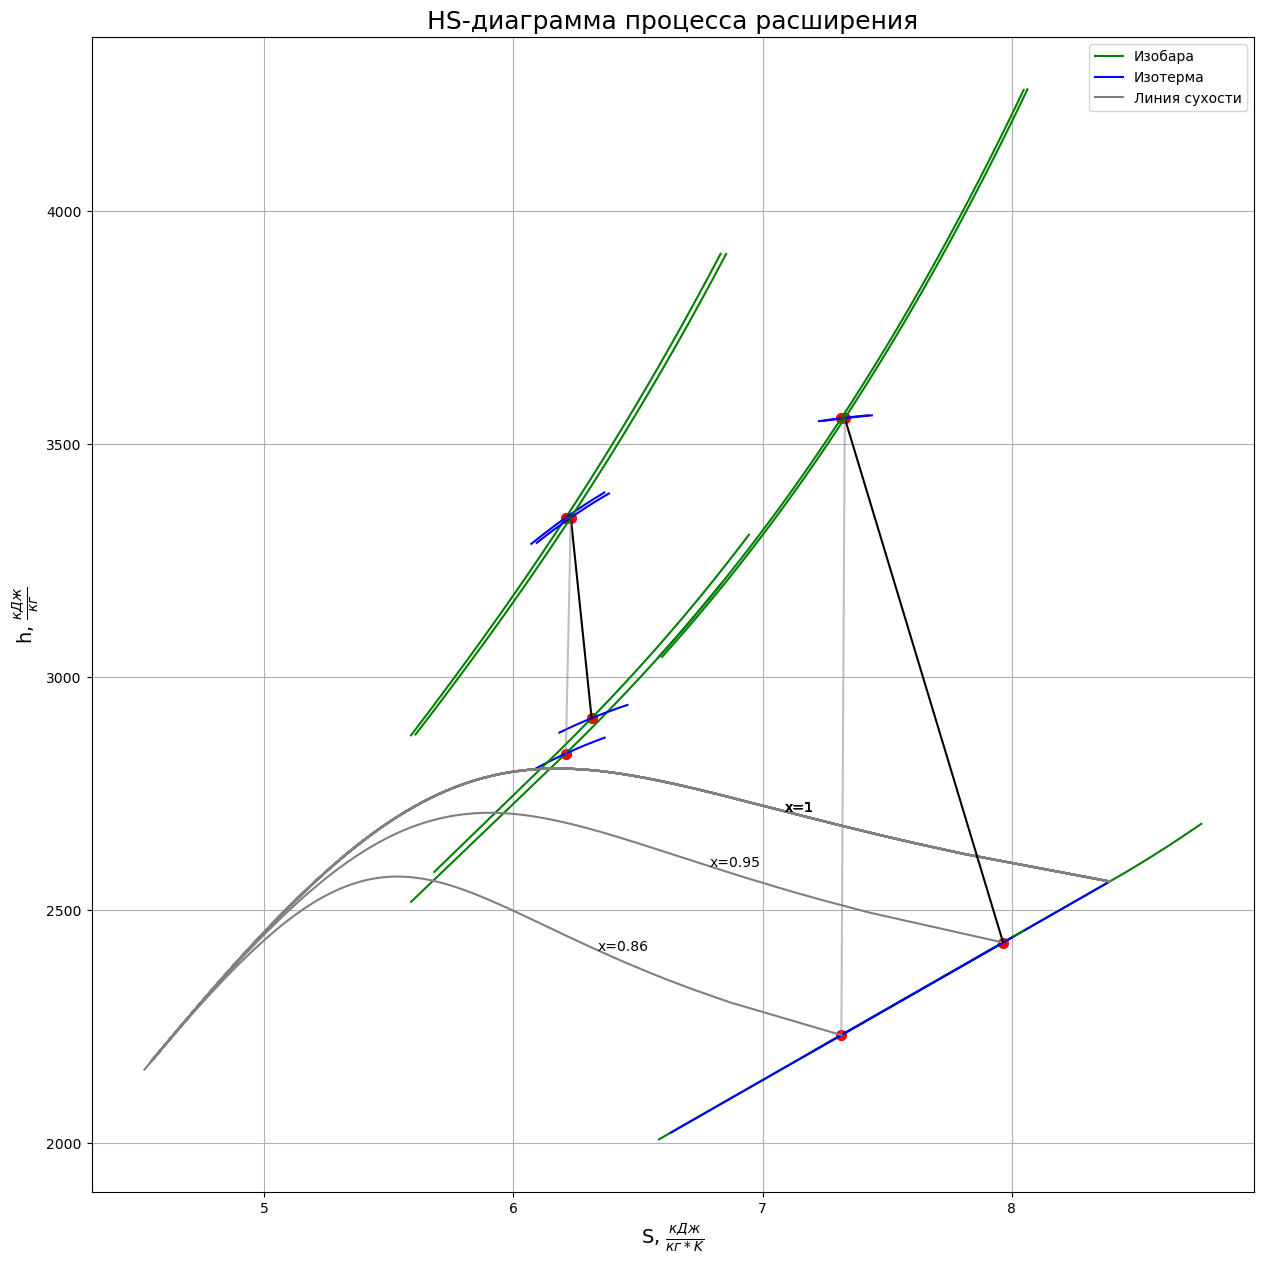

In [100]:
A.all_hs_plot

# Задание 2

Проведение расчёта регулирующей ступени и определние зависимости $\eta_{ол}$ от $U/c_f$. Диапазон варирьуемого параметра - диаметра - задан; обоснованно выбрать вариант исполнения регулирующей ступени для проектирования ЦВД в рамках заданного диапазона

Выберем в качестве сопловой лопатки *С-90-15А*, в качестве рабочей: *Р-26-17А*
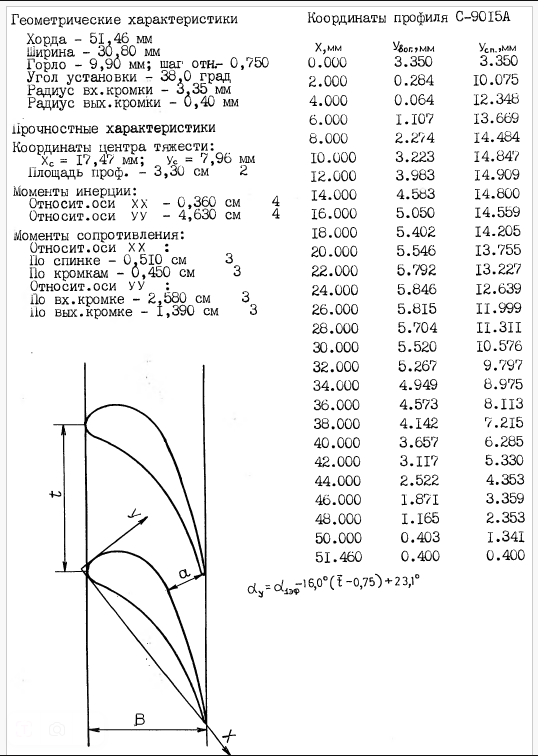
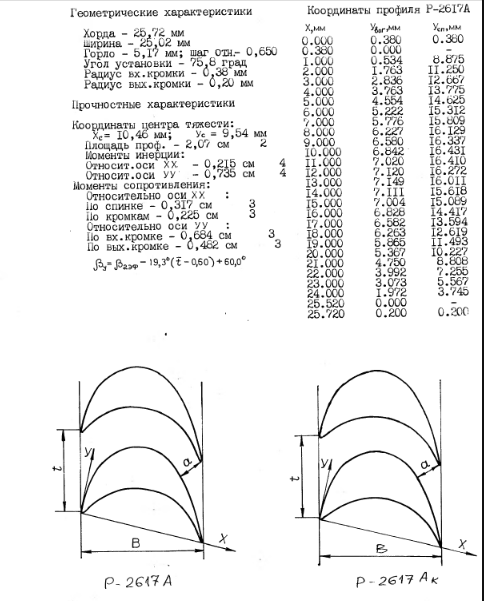

In [101]:
import math
H_0 = 100
B  = cst(my_class, A, d =1.1, n = 60, ro = 0.075 , H_0 = 105, mass_flow= 650, alpha_1e = 14, b_1= 51.5 / 1000, t_1opt = 0.8, b_2 = 51.5 / 1000,t_2opt = 0.8, xi_vs = 0 )

d_r = np.arange(0.9,1.1,0.01) 

_eff_ol_energy = []
_eff_ol_angle = []
_eff_oi = []
_u_cf = []
n = 60
b_1 = 51.5 / 1000
t_1opt = 0.8
alpha_1e = 14
b_2 = 0.070911
t_2opt = 0.8

_eff_ol_energy = []
_eff_ol_angle = []
_eff_oi = []
_u_cf = []
for i in range(len(d_r)):
    B  = cst(my_class, A, d_r[i], n = 60, ro = 0.075 , H_0 = 100, mass_flow= inlet_mass_flow, alpha_1e = 14, b_1= 51.5 / 1000, t_1opt = 0.8, b_2 = 51.5 / 1000,t_2opt = 0.8, xi_vs = 0 )
    _eff_ol_energy.append(B.eff_oi_loss)
    _eff_ol_angle.append(B.eff_oi_velocity)
    _eff_oi.append(B.kpd_oi)
    _u_cf.append((B.u_c_f))
    
print(B.M_1t)

0.6831001373103516


M_1t < 0.85, что соответствует заданному профилю

<>:4: SyntaxWarning:

invalid escape sequence '\e'

<>:5: SyntaxWarning:

invalid escape sequence '\e'

<>:6: SyntaxWarning:

invalid escape sequence '\e'

<>:13: SyntaxWarning:

invalid escape sequence '\e'

<>:20: SyntaxWarning:

invalid escape sequence '\e'

<>:21: SyntaxWarning:

invalid escape sequence '\e'

<>:22: SyntaxWarning:

invalid escape sequence '\e'

<>:4: SyntaxWarning:

invalid escape sequence '\e'

<>:5: SyntaxWarning:

invalid escape sequence '\e'

<>:6: SyntaxWarning:

invalid escape sequence '\e'

<>:13: SyntaxWarning:

invalid escape sequence '\e'

<>:20: SyntaxWarning:

invalid escape sequence '\e'

<>:21: SyntaxWarning:

invalid escape sequence '\e'

<>:22: SyntaxWarning:

invalid escape sequence '\e'

C:\Users\Vait_\AppData\Local\Temp\ipykernel_9500\1937349545.py:4: SyntaxWarning:

invalid escape sequence '\e'

C:\Users\Vait_\AppData\Local\Temp\ipykernel_9500\1937349545.py:5: SyntaxWarning:

invalid escape sequence '\e'

C:\Users\Vait_\AppData\Local\Temp\ipyker

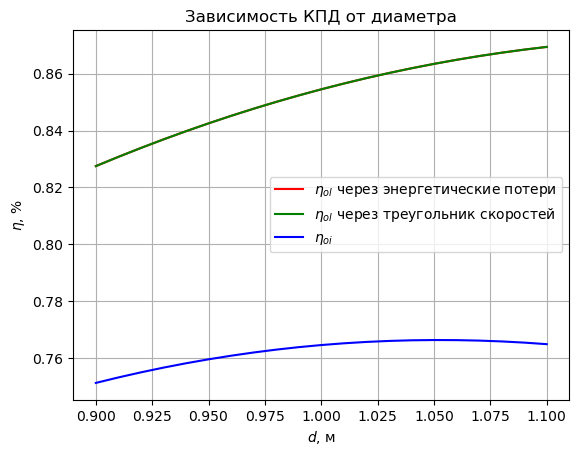

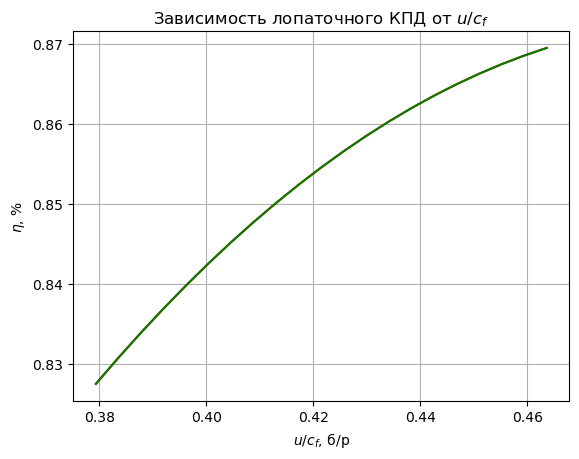

In [102]:
import matplotlib.pyplot as plt
plt.title("Зависимость КПД от диаметра") 
plt.xlabel(f"$d$, м") 
plt.ylabel(f"$\eta$, %")     
plt.plot(d_r,_eff_ol_energy , color ="red", label = "$\eta_{ol}$ через энергетические потери")
plt.plot(d_r,_eff_ol_angle, color ="green",label = "$\eta_{ol}$ через треугольник скоростей")


max_eff = np.argmax(_eff_ol_energy)

d_opt = d_r[max_eff]

plt.plot(d_r,_eff_oi, color ="blue", label = "$\eta_{oi}$")
plt.grid(True)
plt.legend()
plt.show()

plt.title("Зависимость лопаточного КПД от $u/c_f$") 
plt.xlabel(f"$u/c_f$, б/р") 
plt.ylabel(f"$\eta$, %")     
plt.plot(_u_cf,_eff_ol_energy , color ="red", label = "$\eta_{ol}$ через энергетические потери")
plt.plot(_u_cf,_eff_ol_angle, color ="green",label = "$\eta_{ol}$ через треугольник скоростей")
plt.grid(True)
plt.show()

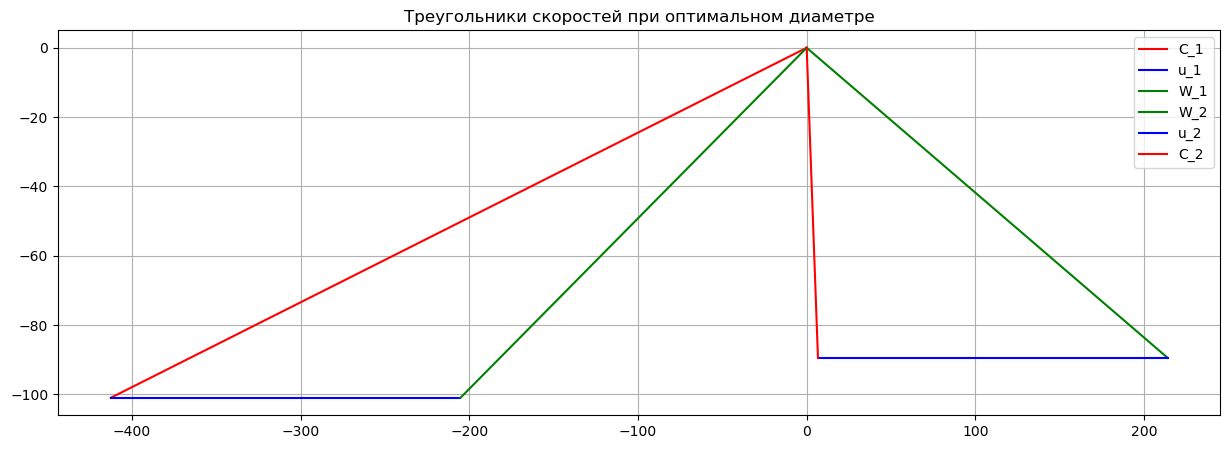

In [103]:
B  = cst(my_class, A, d_opt, n = 60, ro = 0.075 , H_0 = 100, mass_flow= inlet_mass_flow, alpha_1e = 14, b_1= 51.5 / 1000, t_1opt = 0.8, b_2 = 51.5 / 1000,t_2opt = 0.8, xi_vs = 0 )
geom_df, velocity_df, loss_df, thermodynamic_df = B.create_results_tables
B.both_plot_velocity_triangles

In [104]:
loss_df

,"Потери, %"
Тип потерь,
В сопловой решетке,2.267
В рабочей решетке,6.762
Энергия выходной скорости,4.026
Потери от утечек через уплотнение,4.352
Потери от трения диска,0.764
Потери от парциальности,5.343


In [105]:
thermodynamic_df

,"Давление (P), МПа","Температура (T), K","Энтальпия (h), кДж/кг","Энтропия (s), кДж/(кг·K)"
Состояние,,,,
Параметры перед ступенью,22.230,540.605,3342.009,6.231
Теоретические параметры за сопловой решеткой,3.300,248.383,2835.441,6.211
Фактические параметры за сопловой решеткой,3.630,277.768,2911.426,6.314
Теоретические параметры за ступенью,0.005,32.875,2230.982,7.316
Фактические параметры за ступенью,0.005,32.875,2429.654,7.965


In [106]:
velocity_df

,"Абсолютная скорость (с), м/с","Абсолютный угол (α), °","Относительная скорость (w), м/с","Относительный угол (β), °"
Локация,,,,
За сопловой решеткой,424.814,13.756,228.792,26.201
За рабочей решеткой,89.738,85.721,231.995,22.689


In [107]:
geom_df

,"Длина, м"
Геометрия,
Длина рабочей лопатки,0.022996
Длина сопловой лопатки,0.026496
Ширина рабочей лопатки,0.051500
Ширина сопловой лопатки,0.051500


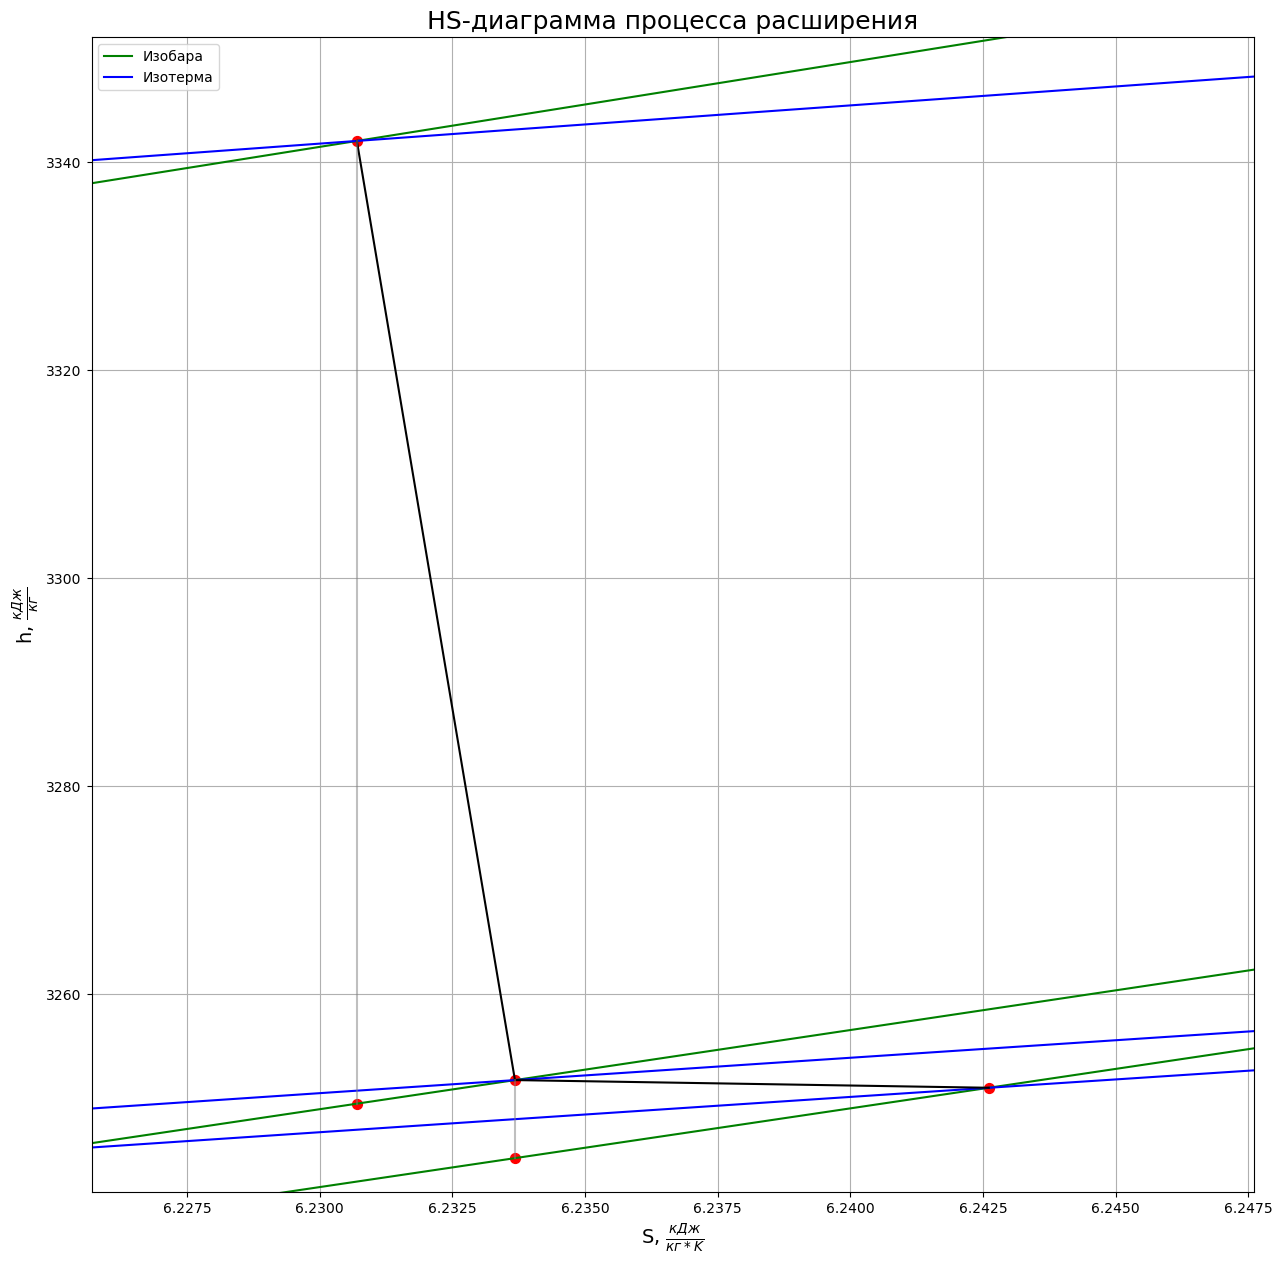

In [108]:
B.hs

In [109]:
sigma_isg, sigma_rast = B.stress(b_2 = 51.5 / 1000, b_2atl = 51.5 / 1000 ,moment_of_resistance_min_atl = 0.45 / 10**6, rho = 7800)
print(sigma_isg, sigma_rast)

0.0651241900264805 16.154473315648968


### 0.182 = $σ_{isg}$  < 20 МПА,  24.85 = $σ_{rast}$ < 450 МПа

## Задание 3 по ступеням

In [110]:
from mass_flow_class import mass_flow_class as mfc
from new_control_stage import MyClass as cst
from steam import Steam as sgas
import numpy as np

In [111]:
MPa = 10 ** 6
kPa = 10 ** 3
unit = 1 / MPa
to_kelvin = lambda x: x + 273.15 if x else None
d_opt = d_opt
H_0 = 100
n = 60
b_1 = 51.5/1000
b_2 = 51.5/1000
t_1opt = 0.8
alpha_1e = 14
t_2opt = 0.8

In [112]:
p0 = 23.4 * MPa
my_class = sgas(name = "Пар", R = 461, c_p =287.05)
A = mfc(my_class,
                    p0 = 23.4 * MPa,
                    t0 = 545,
                    p_middle = 3.3 * MPa ,
                    t_middle = 545 ,
                    pk = 5 * kPa, 
                    t_feed_water = 263,
                    p_feed_water = 1.35 * p0*unit,

                    electrical_power = 320*10**6,
                    internal_efficiency = 0.85,
                    mechanical_efficiency = 0.995,
                    generator_efficiency = 0.99,
                    alpha = 0.83)
B_class = cst(my_class, A, d_opt, n = 60, ro = 0.075 , H_0 = 105, mass_flow= inlet_mass_flow, alpha_1e = 14, b_1= 51.5 / 1000, t_1opt = 0.8, b_2 = 51.5 / 1000,t_2opt = 0.8, xi_vs = 0 )

Ошибка определения веерности:  6.559981101564882 %'
Ошибка определения веерности:  0.24706086184047865 %'
Новое число ступеней:  6.430316458144031


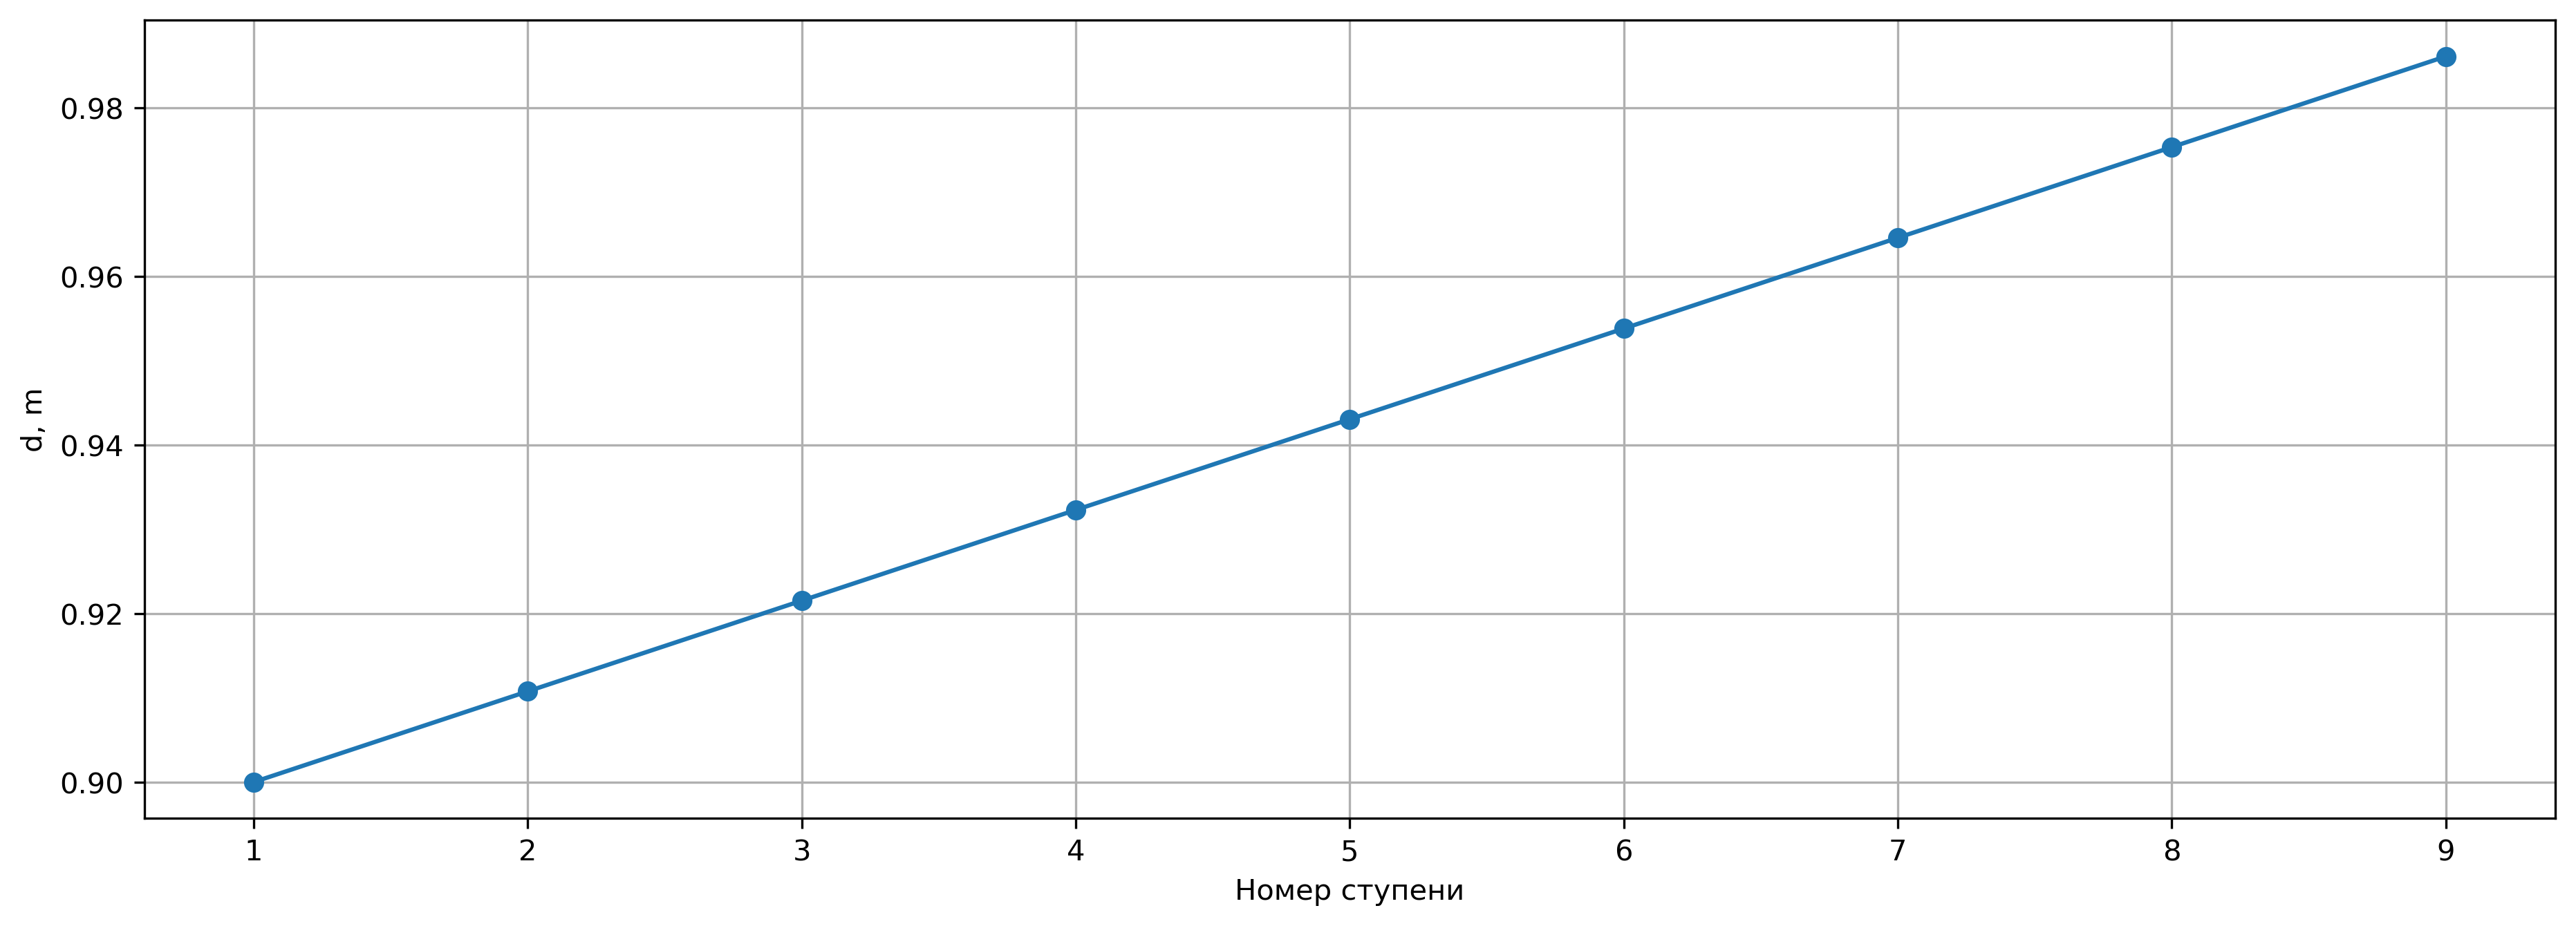

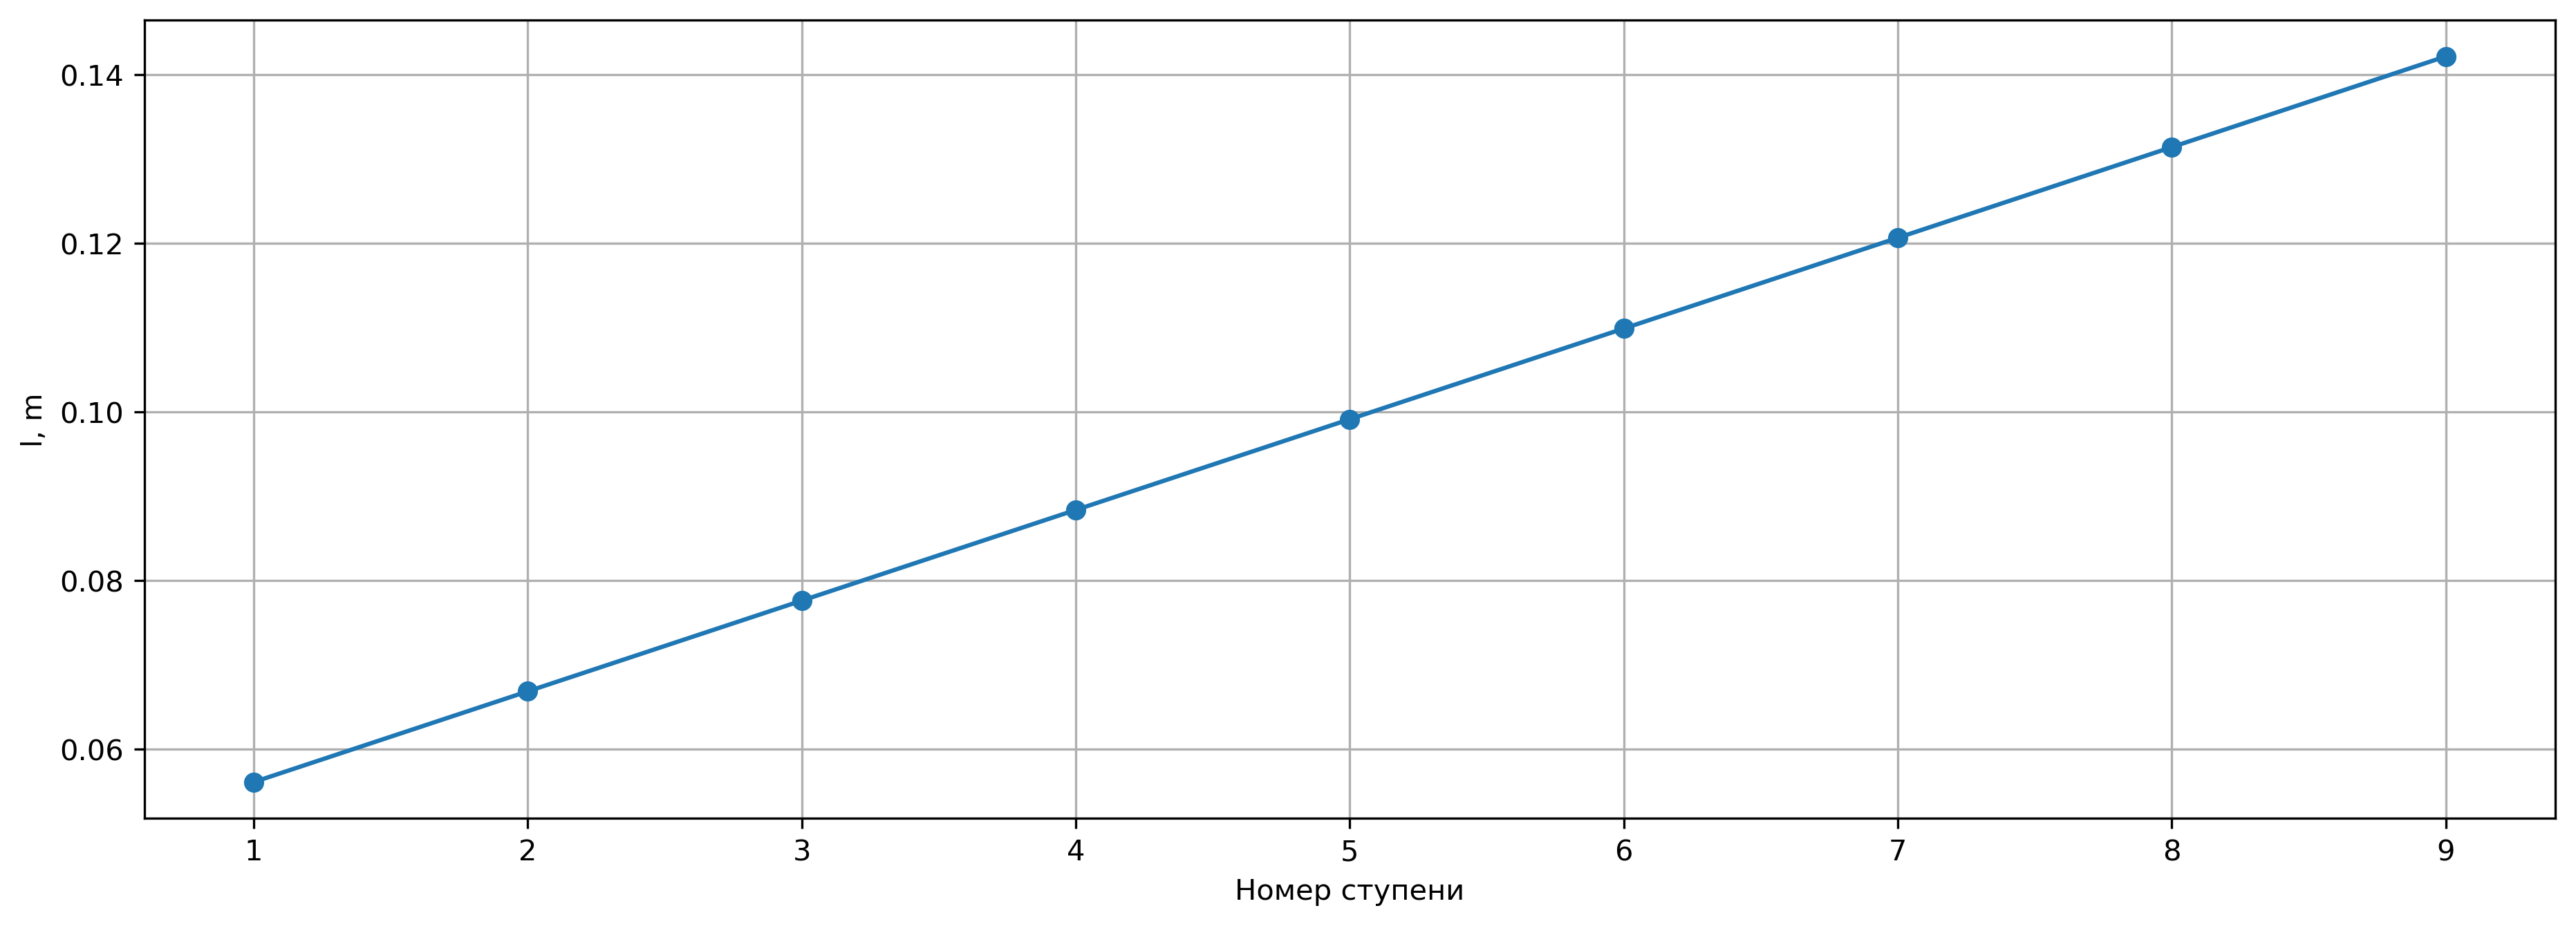

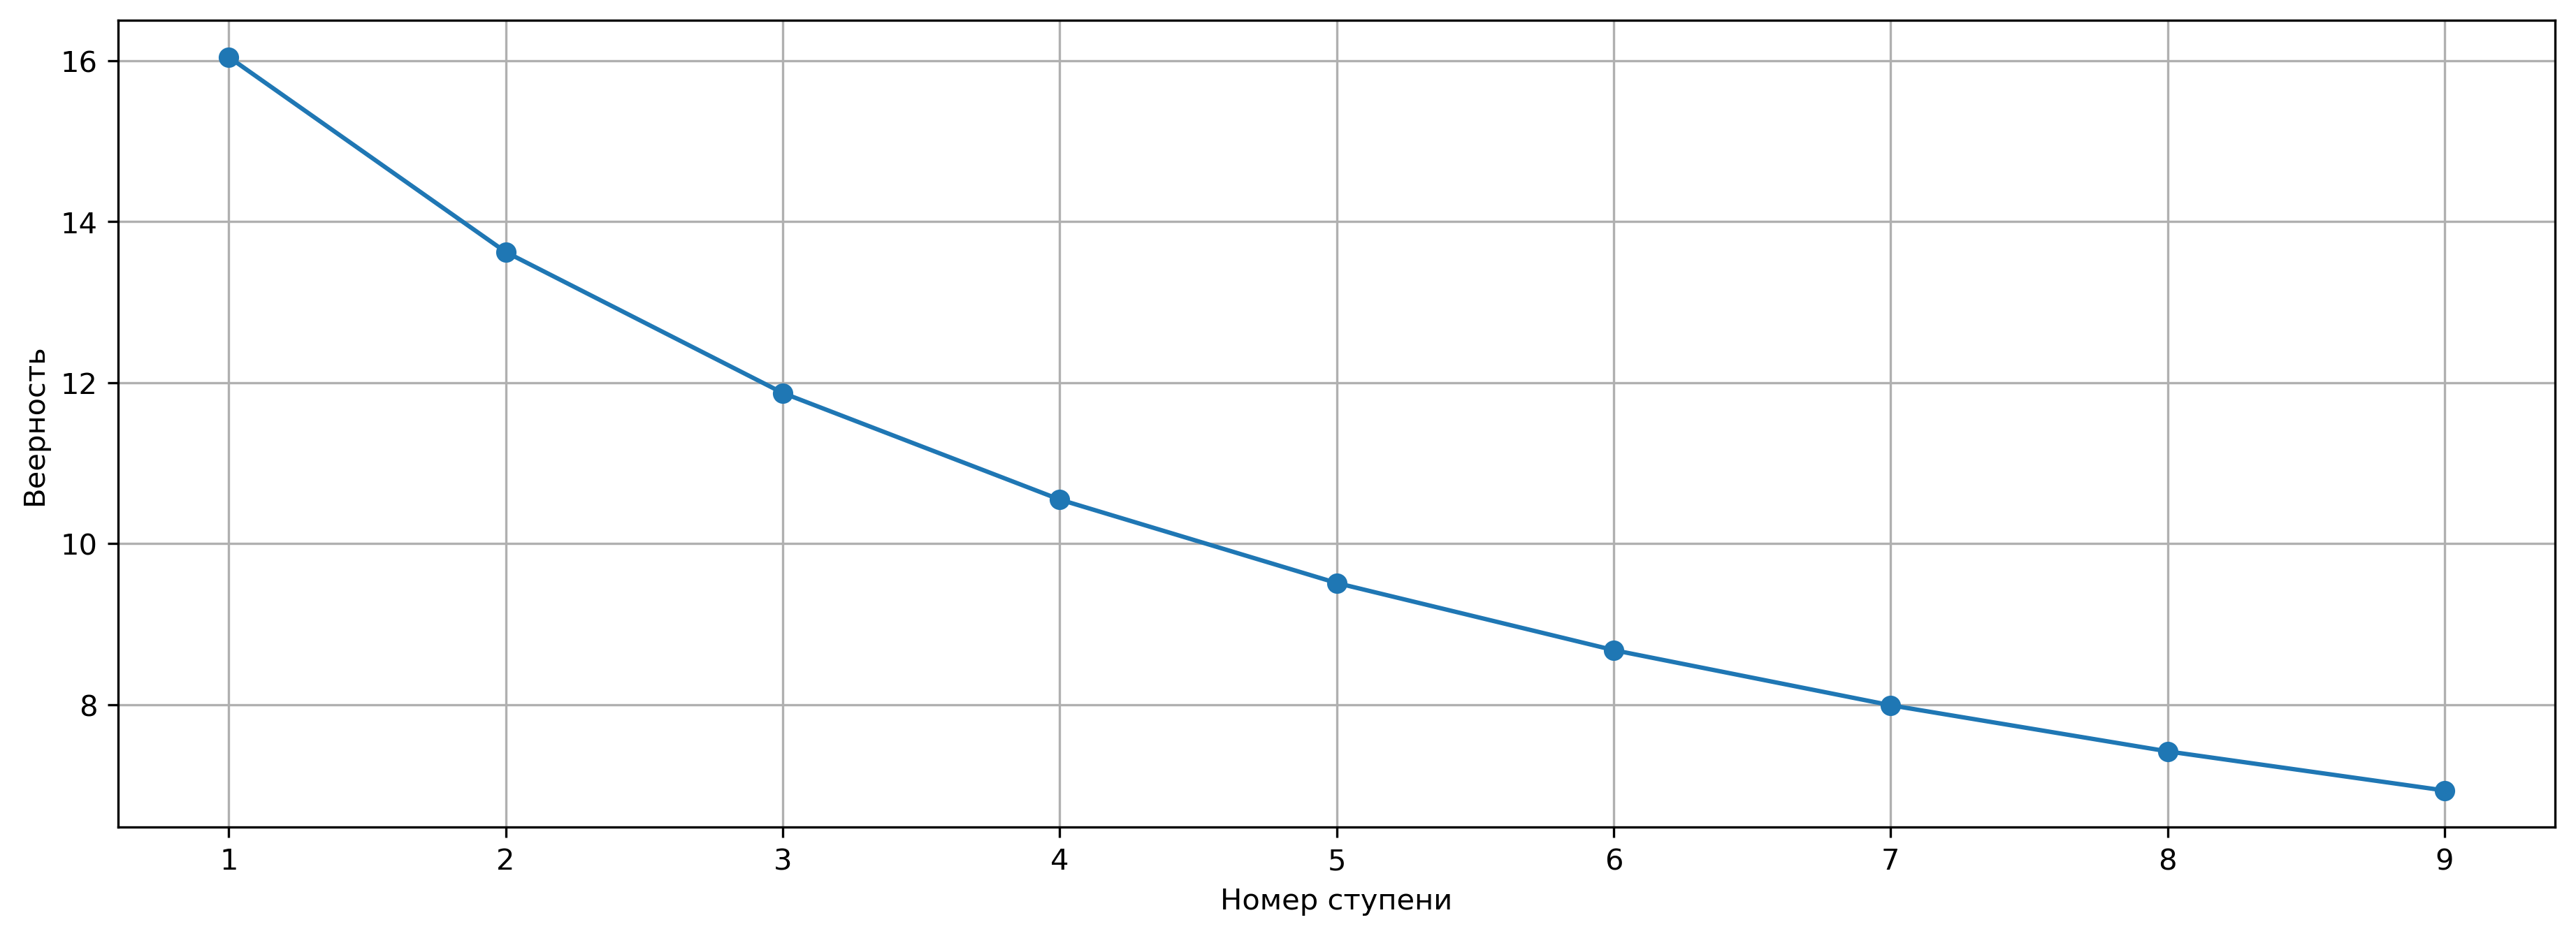

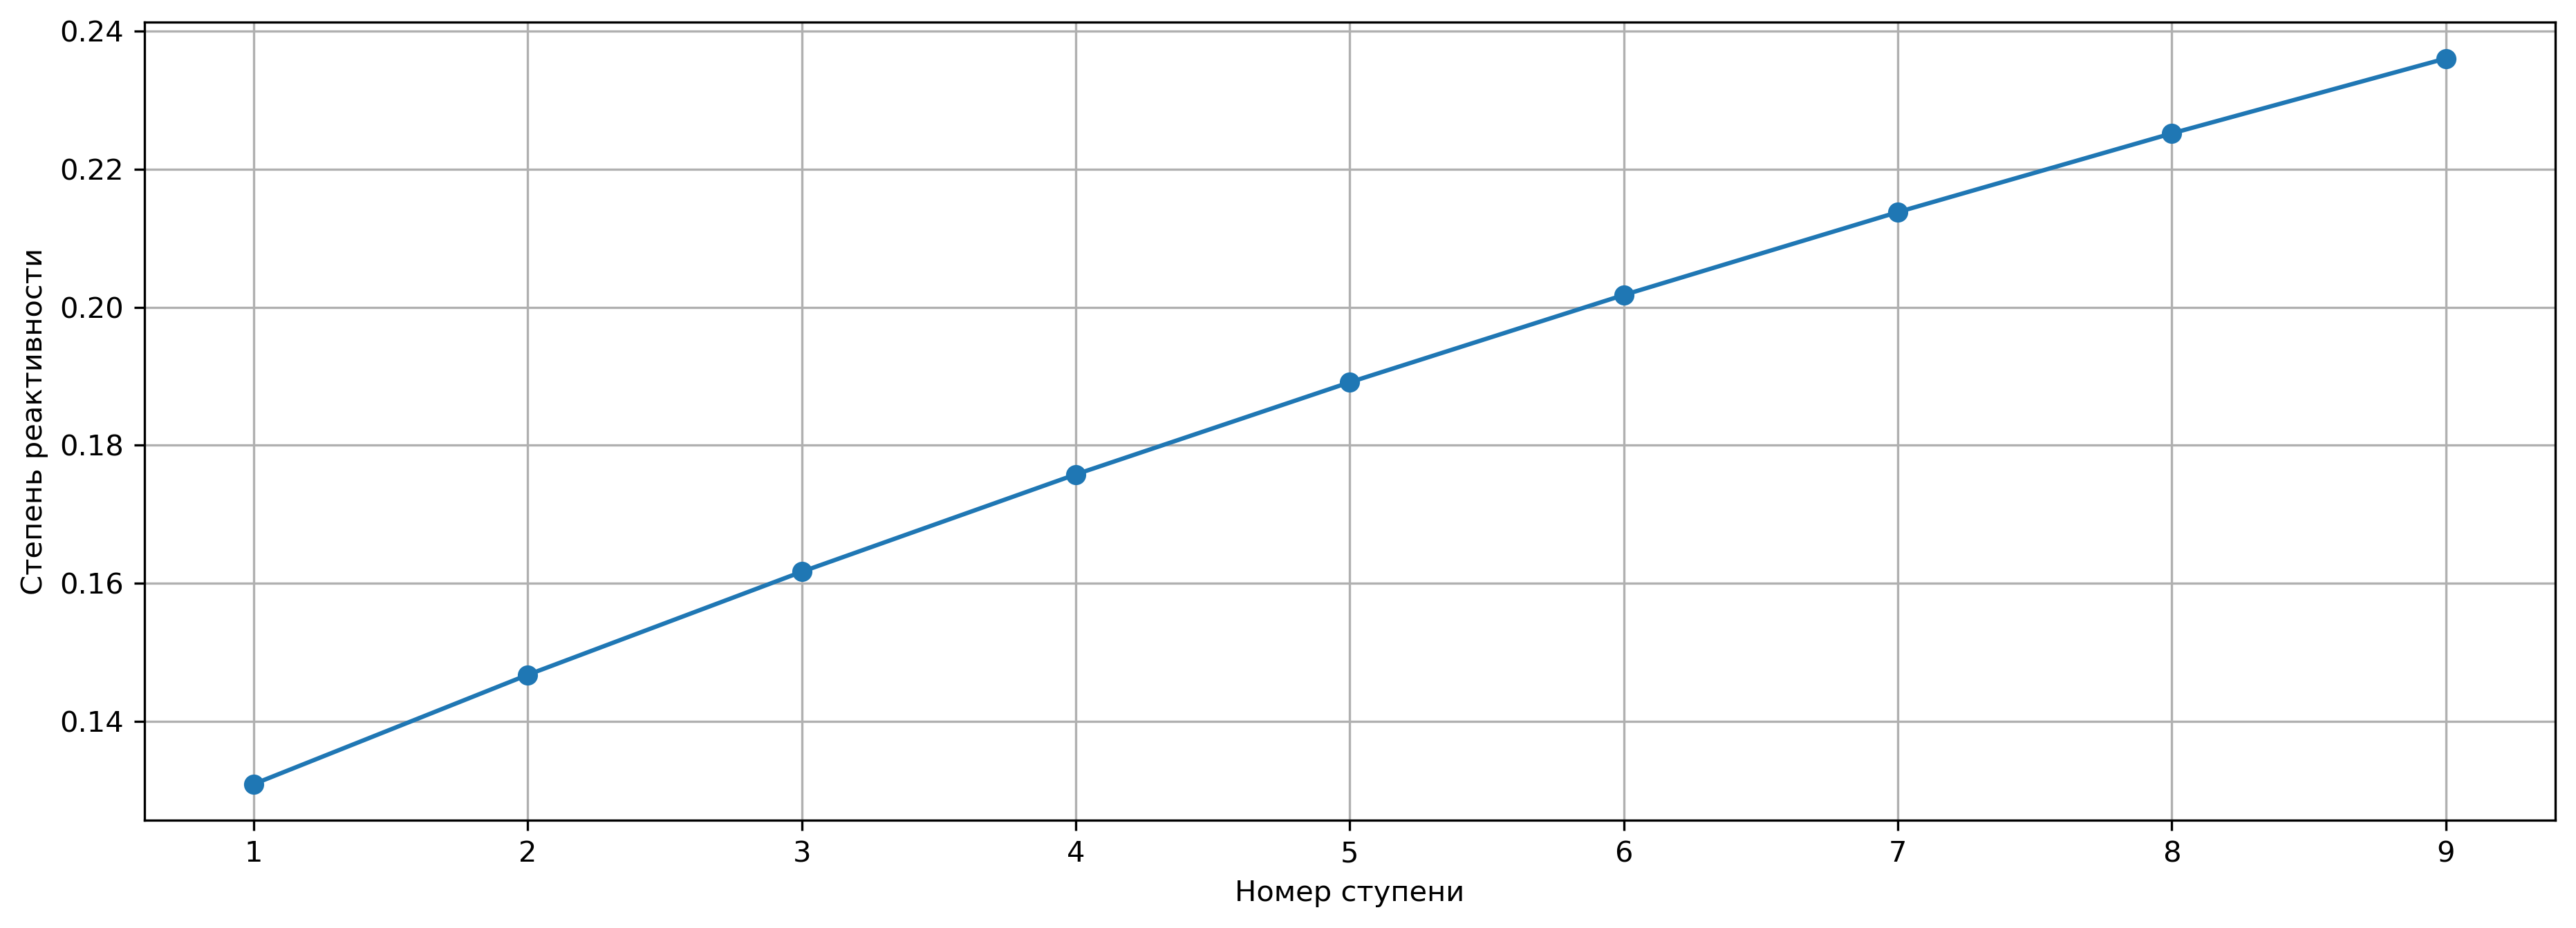

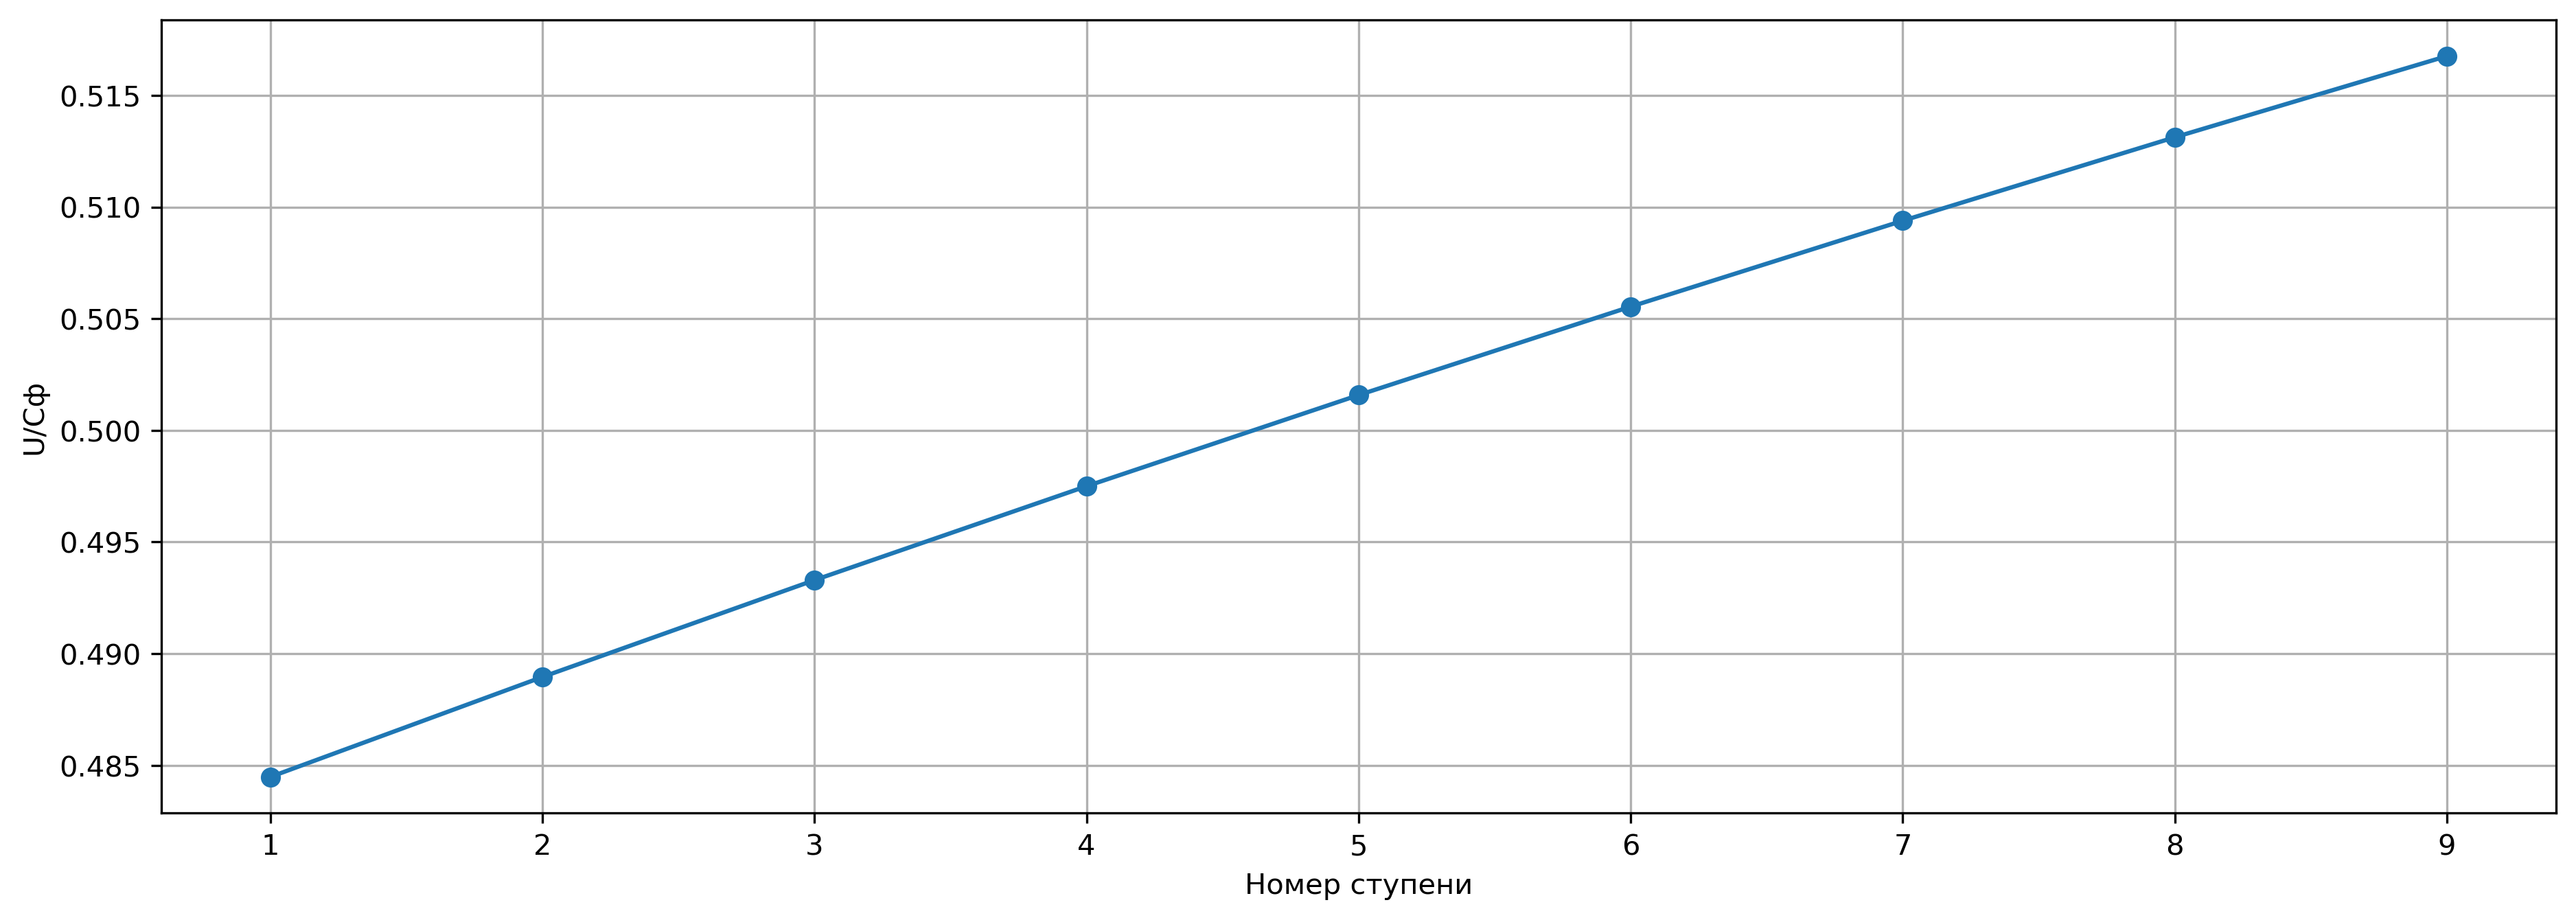

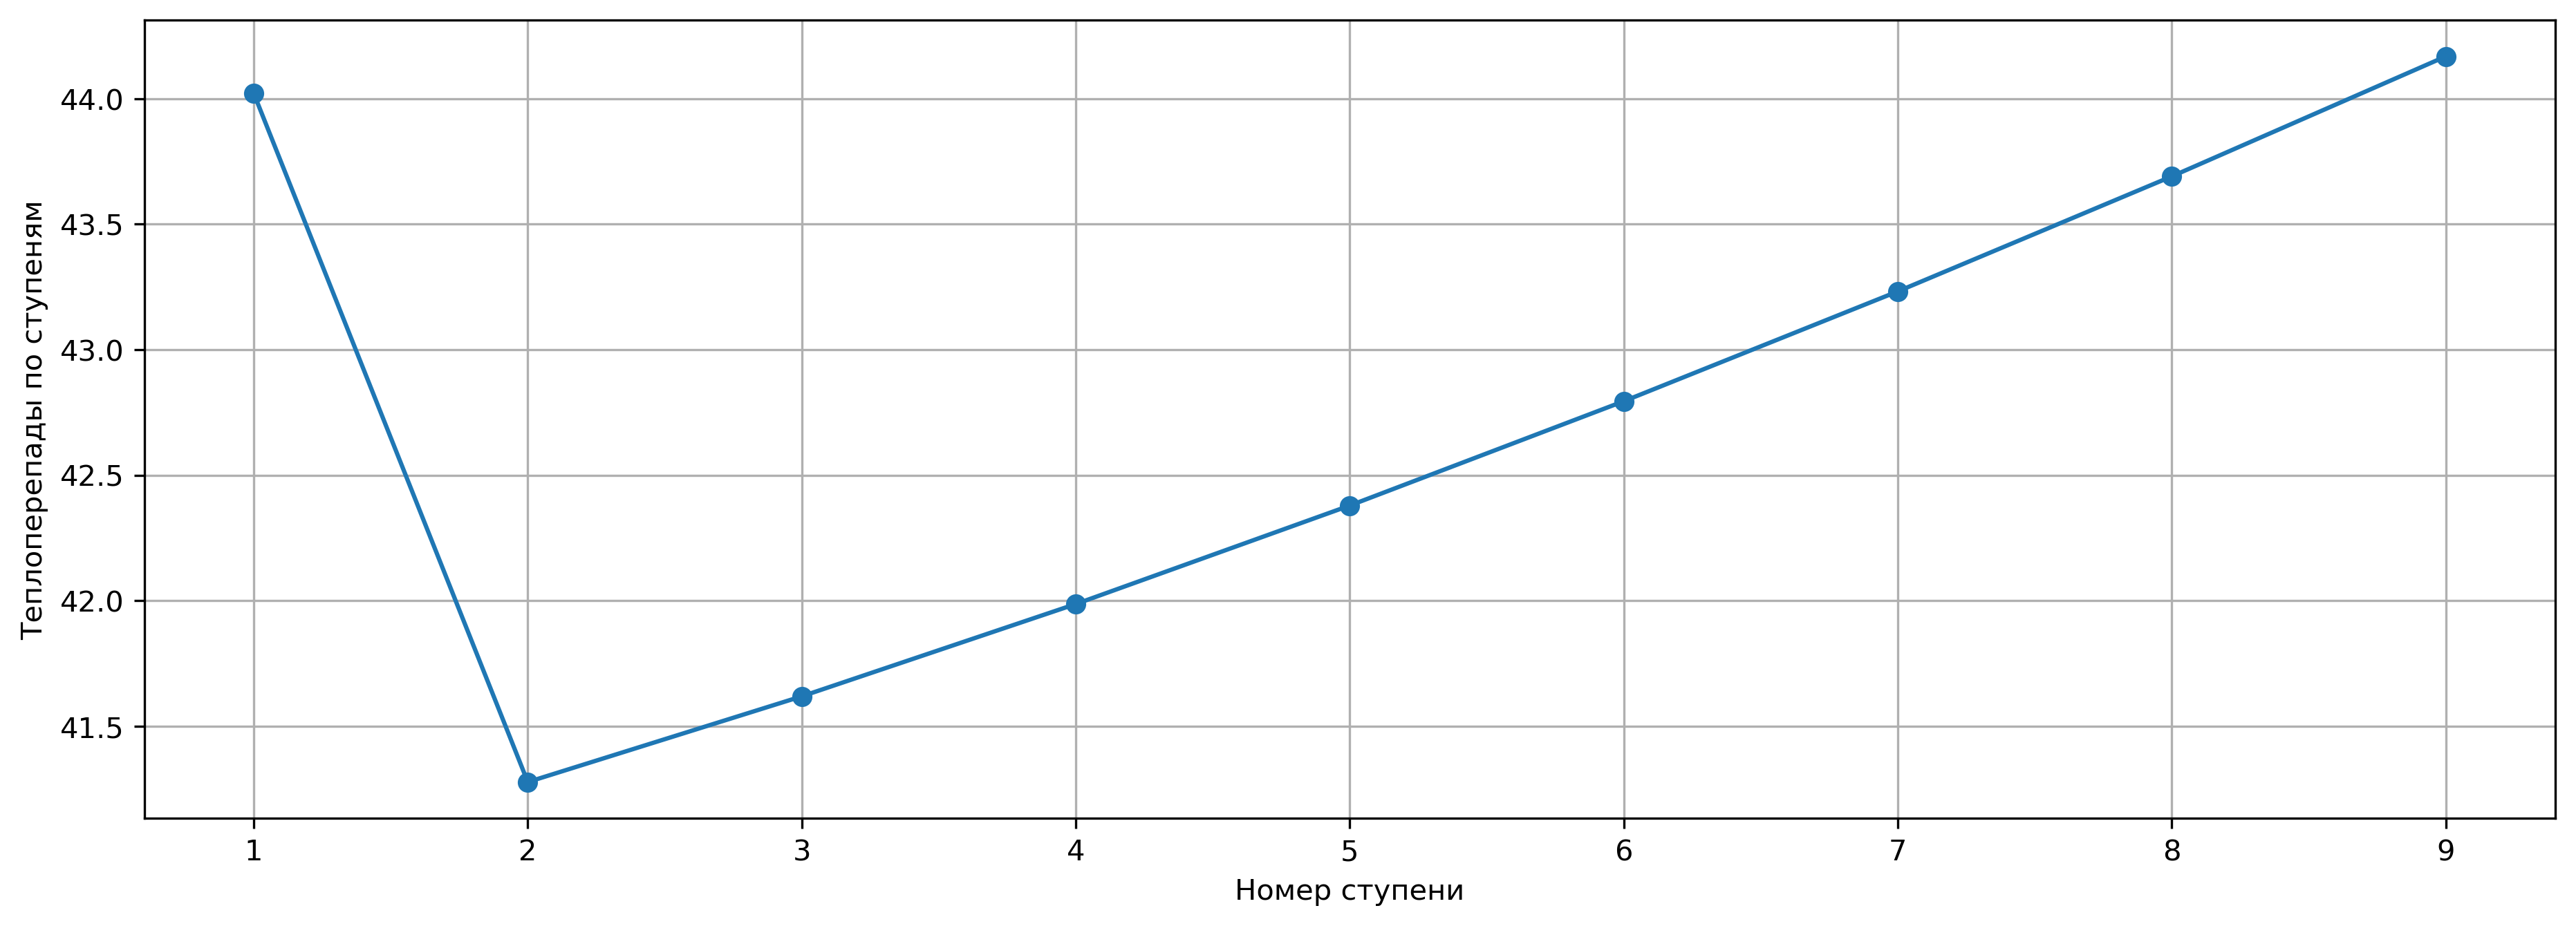

In [113]:
speed_stage_diam =d_opt
rotation_speed = 60
n_stages = 9
mass_flow = inlet_mass_flow

# Techincal params
delta_diam = 0.2
speed_coefficient = 0.93
alpha_1 = 14
root_reaction_degree = 0.05
discharge_coefficient = 0.96
overlapping = 0.003
efficiency = 0.88
veernost_1 = 37
my_blade_No = 8
diameter_my, blade_length_my, veernost_my, reaction_degree_my, u_cf_my, new_actual_heat_drop_my, p_in, T_in, h_in = B_class.blade_update(n_stages,my_blade_No)

## Расчёт ступени номер 1

In [114]:
print(p_in, T_in, h_in)

5.18086 314.41651 2963.80224


Centrifugal stress: 87.27 MPa; Bending stress: 0.37 MPa; Final rotor height: 0.05 m


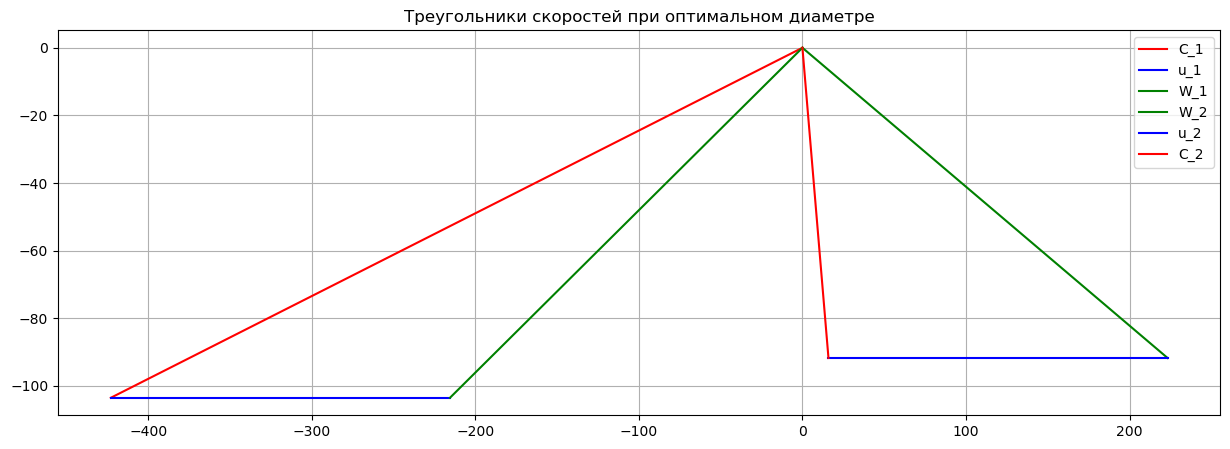

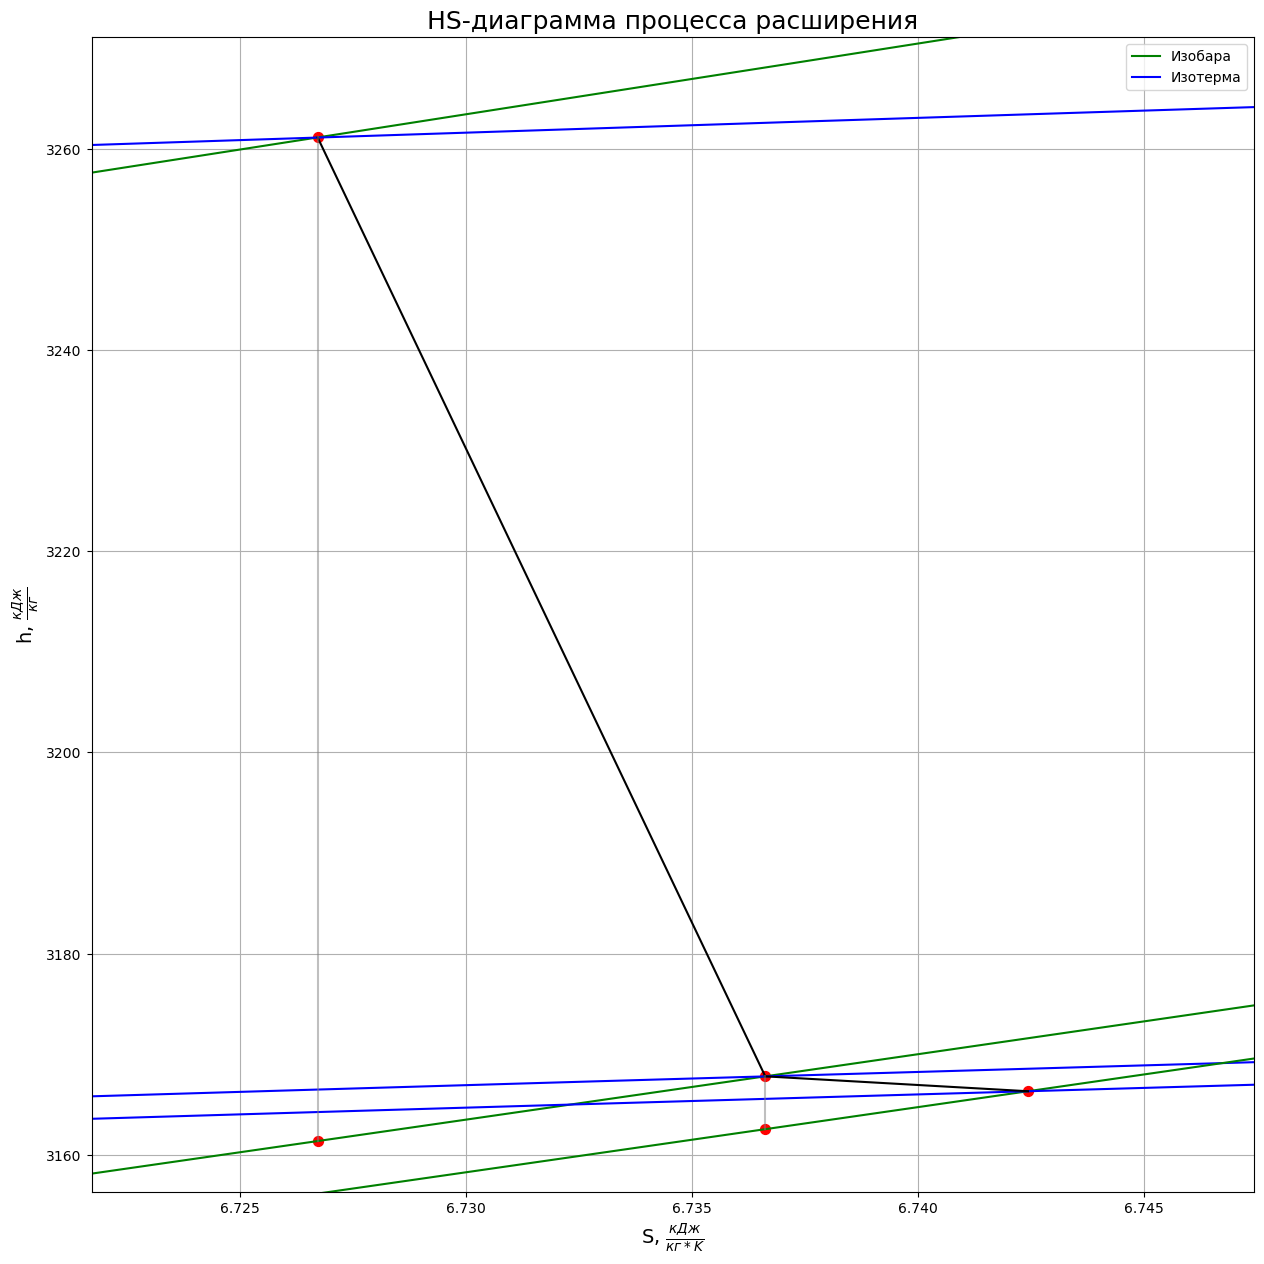

In [115]:
H_o = 100
k = 1.33
n = 60
rho = 0.05
d_r = diameter_my
p0 = p_in 
t0 = T_in
alpha_1_e = 14
t_1opt = (0.7+0.87)/2
t_opt_2 = (0.60+0.70)/2
G = inlet_mass_flow
xi_vs = 1
W_min_atlas = 0.45 / 10**6

eff_ol_energy, eff_ol_angle, eff_oi, u_cf= B_class.my_blade(p0,t0, k, xi_vs, d_r, W_min_atlas ,blade_length_my)

In [116]:
_df = B_class.create_results_tables


In [117]:
_df

(                         Длина, м
 Геометрия                        
 Длина рабочей лопатки    0.022854
 Длина сопловой лопатки   0.026354
 Ширина рабочей лопатки   0.051500
 Ширина сопловой лопатки  0.051500,
                       Абсолютная скорость (с), м/с  Абсолютный угол (α), °  \
 Локация                                                                      
 За сопловой решеткой                       435.305                  13.755   
 За рабочей решеткой                         93.118                  80.155   
 
                       Относительная скорость (w), м/с  \
 Локация                                                 
 За сопловой решеткой                          239.045   
 За рабочей решеткой                           241.383   
 
                       Относительный угол (β), °  
 Локация                                          
 За сопловой решеткой                     25.657  
 За рабочей решеткой                      22.339  ,
                                

## Построением вибрационной диаграммы

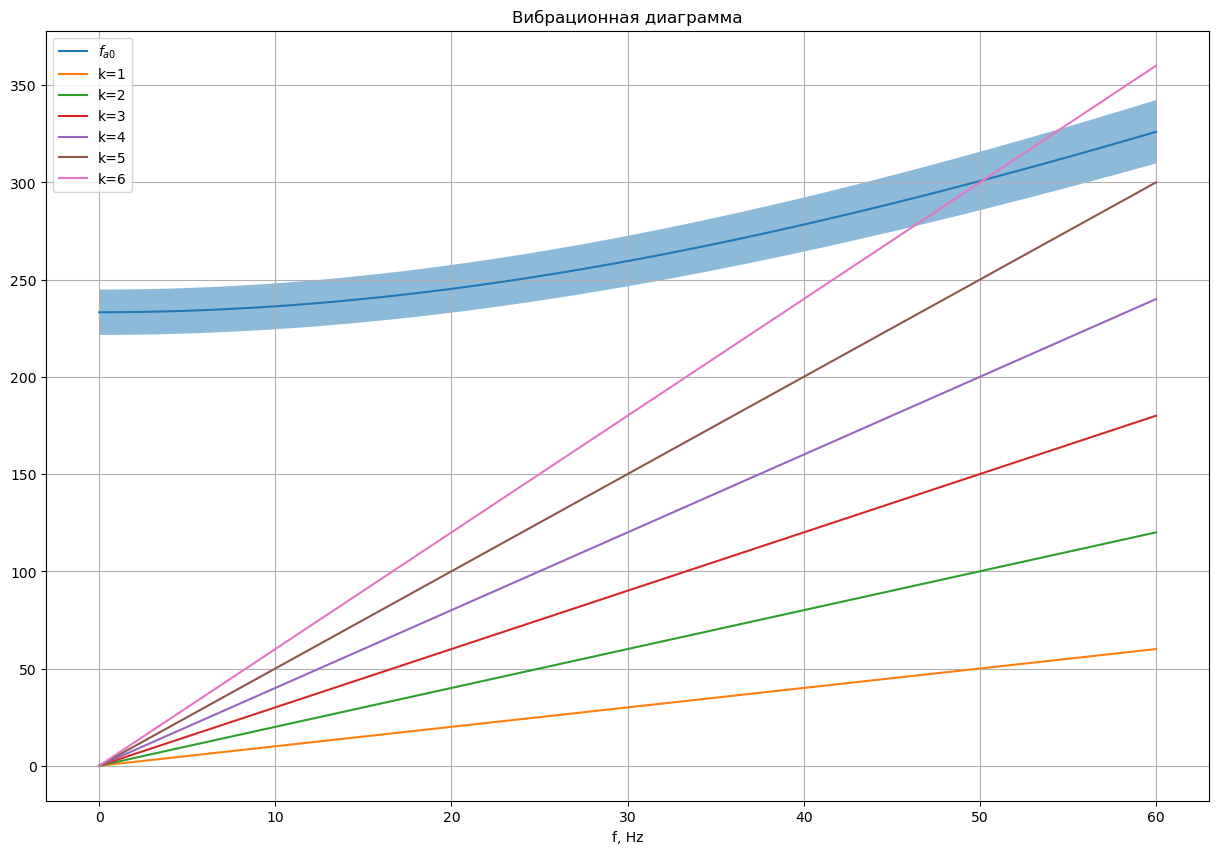

In [118]:
mm = 1/ 1000
m = 12
t = 25 * mm
beta = 85
density = 7900
E = 2 * (10**11)
z = B_class._z_2
d = diameter_my
l = B_class.b_2
f = 0.04498756181811621
J = 0.36 * (10 ** (-8)) 

delta = 5 * mm
Bс = 40 * mm
psi = 0.97
B_class.Vibration_diagram(m, t, beta, density, E,z,d, l,f,J,delta,Bс, psi)

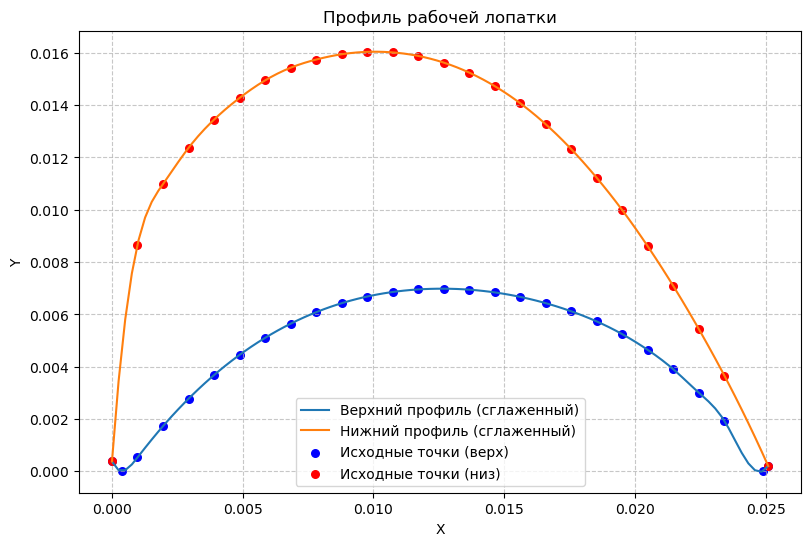

In [119]:
norm_coeff = (25.72/1000)/0.026354
xu = np.array([0,0.38,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.52,25.72])/1000*norm_coeff
xl = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.72])/1000*norm_coeff
yu = np.array([0.38, 0, 0.534,1.763,2.836, 3.763, 4.554, 5.222, 5.776, 6.227,6.58, 6.842, 7.02, 7.12, 7.149, 7.111, 7.004, 6.828, 6.582, 6.263, 5.865, 5.367,4.75,3.992,3.073, 1.972,0, 0.2])/1000*norm_coeff
yl = np.array([0.38, 8.875, 11.25, 12.6667, 13.775, 14.625, 15.312, 15.809, 16.129, 16.337, 16.431, 16.41, 16.272, 16.011, 15.618, 15.089, 14.417, 13.594, 12.619,11.493, 10.227, 8.808, 7.255,5.567,3.745,0.2])/1000 * norm_coeff
B_class.plot_smoothed_profile(xu, yu, xl, yl, num_points=100)

## Представление распределений напряжений:

In [120]:
# xu = np.array([0,0.38,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.52,25.72])/1000
# xl = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.72])/1000
# yu = np.array([0.38, 0, 0.534,1.763,2.836, 3.763, 4.554, 5.222, 5.776, 6.227,6.58, 6.842, 7.02, 7.12, 7.149, 7.111, 7.004, 6.828, 6.582, 6.263, 5.865, 5.367,4.75,3.992,3.073, 1.972,0, 0.2])/1000
# yl = np.array([0.38, 8.875, 11.25, 12.6667, 13.775, 14.625, 15.312, 15.809, 16.129, 16.337, 16.431, 16.41, 16.272, 16.011, 15.618, 15.089, 14.417, 13.594, 12.619,11.493, 10.227, 8.808, 7.255,5.567,3.745,0.2])/1000

# # Создание 3D массива для верхнего профиля (xu, yu, 0.1)
upper_3d = np.column_stack((
    xu, 
    yu, 
    np.full(len(xu), 0.1)  # Z = 0.1 для всех точек верхнего профиля
))

# Создание 3D массива для нижнего профиля (xl, yl, 0.1)
lower_3d = np.column_stack((
    xl, 
    yl, 
    np.full(len(xl), 0.1)  # Z = 0.1 для всех точек нижнего профиля
))

# Объединение в общий 3D массив
combined_3d = np.vstack((upper_3d, lower_3d))

In [121]:
l = blade_length_my 
avg_d = diameter_my
density = 7800
z = 44
n = 60
W = 0.19 * 1e-6
MPa = 10e6

max_stress = 400 * MPa
max_allowed_stress = 235 * MPa

tension_stress_root_func = lambda x: 0.5 * density * (x ** 2) * avg_d * l


angular_speed = 2 * np.pi * n
assert tension_stress_root_func(angular_speed) < max_allowed_stress
print(f"Запас прочности: {max_stress / tension_stress_root_func(angular_speed)}")
increased_angular_speed = 1.1 * angular_speed
assert tension_stress_root_func(increased_angular_speed) < max_allowed_stress
tension_stress_root_func(increased_angular_speed) / MPa
print(f"Запас прочности: {max_stress / tension_stress_root_func(increased_angular_speed)}")

def tension_stress(x):
    r_root = (avg_d - l) / 2
    constant_part = density * (angular_speed ** 2)
    left = r_root * (l - x)
    right = 0.5 * ((l ** 2) - (x ** 2))
    return constant_part * (left + right)

y = np.linspace(0, l, 100)

Запас прочности: 56.29828919942718
Запас прочности: 46.52751173506377


In [122]:
import numpy as np
import matplotlib.pyplot as plt

from functools import partial
from typing import Callable, List, Tuple, Union, Optional

from scipy.integrate import dblquad, quad


def __patch_variable(value: Union[Callable, int, float]) -> Callable:
    """
    Patch variable which should be Callable. Usually it is variable depending on cross-section
    :param Union[Callable, int, float] value:
    :return Callable:
    """
    if callable(value):
        return value
    else:
        return lambda x: value
    
def __patch_multiple(*args) -> List[Callable]:
    """
    Patch multiple variables at time
    :param args: None keyword args
    :return List[Callable]:
    """
    return [__patch_variable(variable) for variable in args]


def _distribution_loading_x(
    z: Union[int, float],
    density: Callable,
    outlet_axial_speed: Callable,
    inlet_tangential_speed: Callable,
    outlet_tangential_speed: Callable,
    pitch: Callable,
) -> float:
    """
    Distribution loading in cross-section of blade profile for blade bending
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Callable density: Density after blade row, kg / m ** 3
    :param Callable outlet_axial_speed: Axial speed behind blade row, m / s
    :param Callable inlet_tangential_speed: Inlet tangential speed, m / s
    :param Callable outlet_tangential_speed: Outlet tangential speed, m / s
    :param Callable pitch: Blade to blade distance at cross-section z
    :return float:
    """
    rho = density(z)
    step = pitch(z)
    outlet_axial_speed_projection = outlet_axial_speed(z)
    inlet_tangential_projection = inlet_tangential_speed(z)
    outlet_tangential_projection = outlet_tangential_speed(z)
    return rho * step * outlet_axial_speed_projection * (inlet_tangential_projection + outlet_tangential_projection)


def _distribution_loading_y(
    z: Union[int, float],
    density: Callable,
    inlet_axial_speed: Callable,
    outlet_axial_speed: Callable,
    inlet_pressure_profile: Callable,
    outlet_pressure_profile: Callable,
    pitch: Callable,
) -> float:
    """
    Distribution loading in cross-section of blade profile for blade bending
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Callable density: Density after blade row, kg / m ** 3
    :param Callable inlet_axial_speed: Axial speed in front of blade row, m / s
    :param Callable outlet_axial_speed: Axial speed behind blade row, m / s
    :param Callable inlet_pressure_profile: Pressure before blade row, Pa
    :param Callable outlet_pressure_profile: Pressure after blade row, Pa
    :param Callable pitch: Blade to blade distance at cross-section z
    :return float:
    """
    rho = density(z)
    step = pitch(z)
    inlet_axial_projection = inlet_axial_speed(z)
    outlet_axial_projection = outlet_axial_speed(z)
    p_in = inlet_pressure_profile(z)
    p_out = outlet_pressure_profile(z)

    speed_part = rho * step * outlet_axial_projection * (inlet_axial_projection - outlet_axial_projection)
    pressure_part = step * (p_in - p_out)

    return speed_part + pressure_part


def _bending_moment_from_distributed_force(
    z: Union[int, float],
    loading: Callable,
    blade_length: Union[int, float],
) -> float:
    """
    Bending loading in cross-section of blade profile for blade bending
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Callable loading: Loading function f(x), probably should be partial
    :param Union[int, float] blade_length: Blade length, m. Upper bound for integral
    :return float:
    """

    def to_integrate(variable):
        return loading(variable) * (variable - z)

    moment = quad(to_integrate, z, blade_length)[0]
    return moment


def _bending_moment_projections(
    z: Union[int, float],
    blade_length: Union[int, float],
    density: Callable,
    inlet_axial_speed: Callable,
    outlet_axial_speed: Callable,
    inlet_tangential_speed: Callable,
    outlet_tangential_speed: Callable,
    inlet_pressure_profile: Callable,
    outlet_pressure_profile: Callable,
    pitch: Callable,
    angle_of_frame: Callable,
    is_rotor: bool = True,
) -> Tuple[float, float]:
    """
    Define min and max bending moments related to axis with min and max inertia moments
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Union[int, float] blade_length: Blade length, m. Upper bound for integral
    :param Callable density: Density after blade row, kg / m ** 3
    :param Callable inlet_axial_speed: Axial speed in front of blade row, m / s
    :param Callable outlet_axial_speed: Axial speed behind blade row, m / s
    :param Callable inlet_tangential_speed: Inlet tangential speed, m / s
    :param Callable outlet_tangential_speed: Outlet tangential speed, m / s
    :param Callable inlet_pressure_profile: Pressure before blade row, Pa
    :param Callable outlet_pressure_profile: Pressure after blade row, Pa
    :param Callable pitch: Blade to blade distance at cross-section z
    :param Callable angle_of_frame: Blade profile angle of frame for min-max inertia moments
    :param bool is_rotor: Binary flag to specify type of blade
    :return Tuple[float, float]: moment eta, moment zeta
    """

    angle_of_frame = __patch_variable(angle_of_frame)
    cos_beta = np.cos(np.deg2rad(angle_of_frame(z)))
    sin_beta = np.sin(np.deg2rad(angle_of_frame(z)))

    loading_x = partial(
        _distribution_loading_y,
        density=density,
        inlet_axial_speed=inlet_axial_speed,
        outlet_axial_speed=outlet_axial_speed,
        inlet_pressure_profile=inlet_pressure_profile,
        outlet_pressure_profile=outlet_pressure_profile,
        pitch=pitch,
    )

    loading_y = partial(
        _distribution_loading_x,
        density=density,
        outlet_axial_speed=outlet_axial_speed,
        inlet_tangential_speed=inlet_tangential_speed,
        outlet_tangential_speed=outlet_tangential_speed,
        pitch=pitch,
    )

    moment_x = _bending_moment_from_distributed_force(
        z=z,
        blade_length=blade_length,
        loading=loading_x,
    )
    moment_y = _bending_moment_from_distributed_force(
        z=z,
        blade_length=blade_length,
        loading=loading_y,
    )

    moment_eta = moment_y * cos_beta + moment_x * sin_beta
    moment_zeta = moment_y * sin_beta - moment_x * cos_beta

    return moment_eta, moment_zeta


def blade_bending_stress(
    z: Union[int, float],
    blade_length: Union[int, float],
    density: Union[Callable, float],
    inlet_axial_speed: Union[Callable, float],
    outlet_axial_speed: Union[Callable, float],
    inlet_tangential_speed: Union[Callable, float],
    outlet_tangential_speed: Union[Callable, float],
    inlet_pressure_profile: Union[Callable, float],
    outlet_pressure_profile: Union[Callable, float],
    pitch: Union[Callable, float],
    angle_of_frame: Union[Callable, float],
    eta_moment_inertia: Union[Callable, float],
    zeta_moment_inertia: Union[Callable, float],
    coordinates: Union[Tuple[float, float], np.ndarray],
    is_rotor: bool = True,
) -> Union[np.ndarray, float]:
    """
    Define stress from bending moment at specific cross-section Z and coordinates of profile
    :param Union[int, float] z: cross-section coordinate from z to blade length
    :param Union[int, float] blade_length: Blade length, m. Upper bound for integral
    :param Union[Callable, float] density: Density after blade row, kg / m ** 3
    :param Union[Callable, float] inlet_axial_speed: Axial speed in front of blade row, m / s
    :param Union[Callable, float] outlet_axial_speed: Axial speed behind blade row, m / s
    :param Union[Callable, float] inlet_tangential_speed: Inlet tangential speed, m / s
    :param Union[Callable, float] outlet_tangential_speed: Outlet tangential speed, m / s
    :param Union[Callable, float] inlet_pressure_profile: Pressure before blade row, Pa
    :param Union[Callable, float] outlet_pressure_profile: Pressure after blade row, Pa
    :param Union[Callable, float] pitch: Blade to blade distance at cross-section z
    :param Union[Callable, float] angle_of_frame: Blade profile angle of frame for min-max inertia moments
    :param Union[Callable, float] zeta_moment_inertia: Max moment of inertia, m ** 4
    :param Union[Callable, float] eta_moment_inertia: Min moment of inertia, m ** 4
    :param Union[Tuple[float, float], np.ndarray] coordinates: Coordinates of profile to compute stress at this point.
        First coordinate related axis with min moment if inertia, second with max one. (eta_coordinate, zeta_coordinate)
    :param bool is_rotor: Binary flag to specify type of blade
    :return Union[float, np.ndarray]:
    """

    (
        density,
        inlet_axial_speed,
        outlet_axial_speed,
        inlet_tangential_speed,
        outlet_tangential_speed,
        inlet_pressure_profile,
        outlet_pressure_profile,
        pitch,
        zeta_moment_inertia,
        eta_moment_inertia,
        angle_of_frame,
    ) = __patch_multiple(
        density,
        inlet_axial_speed,
        outlet_axial_speed,
        inlet_tangential_speed,
        outlet_tangential_speed,
        inlet_pressure_profile,
        outlet_pressure_profile,
        pitch,
        zeta_moment_inertia,
        eta_moment_inertia,
        angle_of_frame,
    )

    moment_eta, moment_zeta = _bending_moment_projections(
        z=z,
        blade_length=blade_length,
        density=density,
        inlet_axial_speed=inlet_axial_speed,
        outlet_axial_speed=outlet_axial_speed,
        inlet_tangential_speed=inlet_tangential_speed,
        outlet_tangential_speed=outlet_tangential_speed,
        inlet_pressure_profile=inlet_pressure_profile,
        outlet_pressure_profile=outlet_pressure_profile,
        pitch=pitch,
        angle_of_frame=angle_of_frame,
        is_rotor=is_rotor,
    )
    if isinstance(coordinates, np.ndarray):
        if coordinates.ndim == 2:
            stress = (-moment_eta * coordinates[:, 1] / eta_moment_inertia(z)) + (
                moment_zeta * coordinates[:, 0] / zeta_moment_inertia(z)
            )
            return stress

    stress = (-moment_eta * coordinates[1] / eta_moment_inertia(z)) + (
        moment_zeta * coordinates[0] / zeta_moment_inertia(z)
    )

    return stress
def rotate(x: np.ndarray, angle: float) -> np.ndarray:
    """
    Rotate x around [0, 0] on `angle` degree
    :param np.ndarray x: [[x1, x2, x3,...], [y1, y2, y3, ...]]
    :param float angle: Angle in degree to rotate
    :return np.ndarray:
    """
    _angle = np.deg2rad(angle)
    rotation_matrix = np.array([[np.cos(_angle), -np.sin(_angle)], [np.sin(_angle), np.cos(_angle)]])

    return x.dot(rotation_matrix)

def bending_stress_coordinates(full_points, angle_of_frame, diameter) -> np.ndarray:
    """
    Full coordinates of profile to compute bending blade stress
    :return np.ndarray: np.ndarray([eta, zeta. Z])
    """
    coordinates = rotate(full_points[:, [0, 1]], 90 + angle_of_frame)
    coordinates[:, [0, 1]] = coordinates[:, [1, 0]]
    diameter = np.ones_like(coordinates[:, 0])[:, None] * diameter
    coordinates = np.hstack((coordinates, diameter))
    return coordinates

full_points = combined_3d
coordinates = bending_stress_coordinates(full_points=combined_3d, angle_of_frame=33.2, diameter=diameter_my)
coordinates.shape

(54, 3)

In [123]:
# from iapws import IAPWS97


P_in = 22.230  * 1e6
P_out = 3.63 * 1e6
# random_point = IAPWS97(P=P_out / 1e6, T=500)

inlet_axial_speed = 93
outlet_axial_speed = 435.305
inlet_tangential_speed = 239.045
outlet_tangential_speed = 241
eta_moment_inertia = i_minimum = 0.575
zeta_moment_inertia = i_maximum = 1.74
angle_of_frame = 75.8
angle_of_frame = angle_of_frame + 90
density = 7900
blade_length = blade_length_my

bending_stress = blade_bending_stress(
    z=0.05,
    blade_length=blade_length,
    density=density,
    inlet_axial_speed=inlet_axial_speed,
    outlet_axial_speed=outlet_axial_speed,
    inlet_tangential_speed=inlet_tangential_speed,
    outlet_tangential_speed=outlet_tangential_speed,
    inlet_pressure_profile=P_in,
    outlet_pressure_profile=P_out,
    pitch=0.65,
    angle_of_frame=angle_of_frame,
    eta_moment_inertia=eta_moment_inertia,
    zeta_moment_inertia=zeta_moment_inertia,
    coordinates=coordinates,
) / 1e6


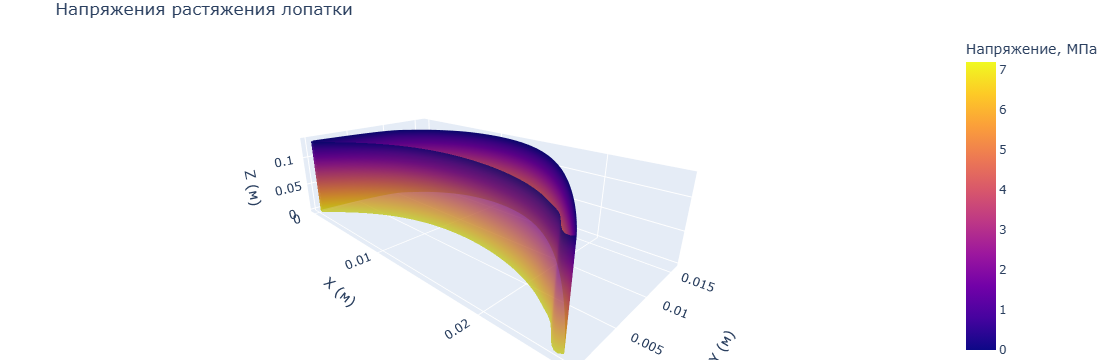

In [124]:
import numpy as np
from scipy.interpolate import interp1d
import plotly.graph_objects as go

def plot_3d_blade_with_stress(xu, yu, xl, yl, stress_distribution, 
                             height=0.1, num_points=100):
    # Интерполяция профилей
    f_u = interp1d(xu, yu, kind='cubic')
    x_u = np.linspace(min(xu), max(xu), num_points)
    y_u = f_u(x_u)
    
    f_l = interp1d(xl, yl, kind='cubic')
    x_l = np.linspace(min(xl), max(xl), num_points)
    y_l = f_l(x_l)

    # Создание координат по Z (включая верхнее и нижнее сечения)
    z_coords = np.linspace(0, height, num_points)
    
    # Интерполяция напряжений по высоте Z
    stress_interp = interp1d(np.linspace(0, height, len(stress_distribution)),
                            stress_distribution,
                            kind='linear',
                            fill_value='extrapolate')
    
    # Создание 3D сетки
    X_u, Z_u = np.meshgrid(x_u, z_coords)
    Y_u = np.array([y_u]*num_points)
    
    X_l, Z_l = np.meshgrid(x_l, z_coords)
    Y_l = np.array([y_l]*num_points)
    
    # Распределение напряжений по Z
    stress = stress_interp(z_coords)[:, np.newaxis]

    fig = go.Figure()
    
    # Верхняя поверхность
    fig.add_trace(go.Surface(
        x=X_u,
        y=Y_u,
        z=Z_u,
        surfacecolor=np.repeat(stress, len(x_u), axis=1),
        colorscale='Plasma',
        opacity=0.8,
        showscale=True,
        name='Напряжения',
        colorbar=dict(title='Напряжение, МПа')
    ))
    
    # Нижняя поверхность
    fig.add_trace(go.Surface(
        x=X_l,
        y=Y_l,
        z=Z_l,
        surfacecolor=np.repeat(stress, len(x_l), axis=1),
        colorscale='Plasma',
        showscale=False
    ))
    
    # Боковые поверхности
    for i in [0, -1]:  # Передняя и задняя кромки
        fig.add_trace(go.Surface(
            x=np.array([[xu[i], xl[i]]]*num_points),
            y=np.array([[yu[i], yl[i]]]*num_points),
            z=np.array([z_coords, z_coords]).T,
            surfacecolor=stress,
            colorscale='Plasma',
            showscale=False
        ))
    
    # Настройки отображения
    fig.update_layout(
        title='Напряжения растяжения лопатки',
        scene=dict(
            xaxis_title='X (м)',
            yaxis_title='Y (м)',
            zaxis_title='Z (м)',
            aspectmode='manual',
            aspectratio=dict(x=2, y=1, z=0.5),
            camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
        ),
        margin=dict(l=0, r=50, b=0, t=30)
    )
    
    fig.show()


stress_values =tension_stress(y)/MPa# np.linspace(50, 100, len(xu))


plot_3d_blade_with_stress(xu, yu, xl, yl, 
                         stress_distribution=stress_values,
                         height=blade_length_my,
                         num_points=100)

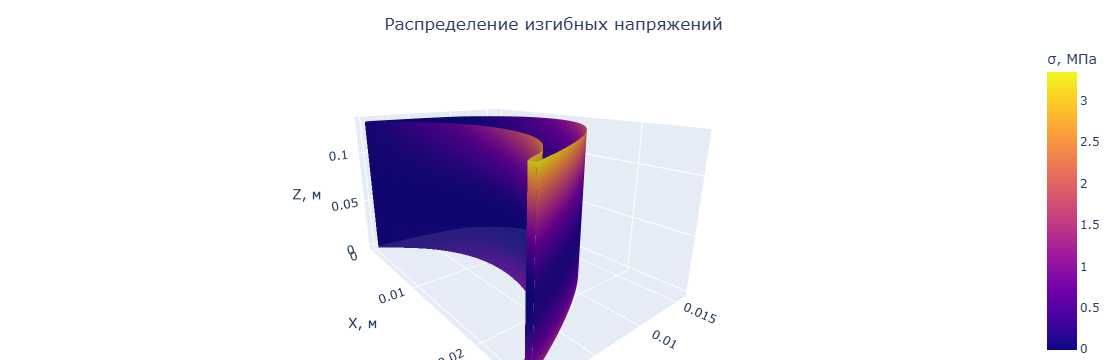

In [125]:
import numpy as np
from scipy.interpolate import interp1d
import plotly.graph_objects as go

def plot_3d_bending_stress(xu, yu, xl, yl, 
                          blade_length, density,
                          inlet_axial_speed, outlet_axial_speed,
                          inlet_tangential_speed, outlet_tangential_speed,
                          inlet_pressure_profile, outlet_pressure_profile,
                          pitch, angle_of_frame,
                          eta_moment_inertia, zeta_moment_inertia,
                          height=0.1, num_points=100):
    # Интерполяция профилей
    f_u = interp1d(xu, yu, kind='cubic')
    x_u = np.linspace(min(xu), max(xu), num_points)
    y_u = f_u(x_u)
    
    f_l = interp1d(xl, yl, kind='cubic')
    x_l = np.linspace(min(xl), max(xl), num_points)
    y_l = f_l(x_l)

    # Генерация 3D сетки
    z_levels = np.linspace(0, height, num_points)
    X_u, Z_u = np.meshgrid(x_u, z_levels)
    Y_u = np.array([y_u]*num_points)
    
    X_l, Z_l = np.meshgrid(x_l, z_levels)
    Y_l = np.array([y_l]*num_points)

    # Инициализация массивов напряжений
    stress_upper = np.zeros_like(X_u)
    stress_lower = np.zeros_like(X_l)

    # Расчет напряжений для каждого сечения
    for i, z in enumerate(z_levels):
        # Координаты для верхнего профиля
        coords_upper = np.column_stack([x_u, y_u, np.full_like(x_u, z)])
        
        # Координаты для нижнего профиля
        coords_lower = np.column_stack([x_l, y_l, np.full_like(x_l, z)])
        
        # Объединение координат
        all_coords = np.vstack([coords_upper, coords_lower])
        
        # Расчет напряжений
        stresses = blade_bending_stress(
            z=z,
            blade_length=blade_length,
            density=density,
            inlet_axial_speed=inlet_axial_speed,
            outlet_axial_speed=outlet_axial_speed,
            inlet_tangential_speed=inlet_tangential_speed,
            outlet_tangential_speed=outlet_tangential_speed,
            inlet_pressure_profile=inlet_pressure_profile,
            outlet_pressure_profile=outlet_pressure_profile,
            pitch=pitch,
            angle_of_frame=angle_of_frame,
            eta_moment_inertia=eta_moment_inertia,
            zeta_moment_inertia=zeta_moment_inertia,
            coordinates=all_coords
        ) / 1e6  # Конвертация в МПа
        
        # Разделение результатов
        stress_upper[i] = stresses[:len(x_u)]
        stress_lower[i] = stresses[len(x_u):]

    # Создание 3D визуализации
    fig = go.Figure()
    
    # Верхняя поверхность
    fig.add_trace(go.Surface(
        x=X_u,
        y=Y_u,
        z=Z_u,
        surfacecolor=stress_upper,
        colorscale='Plasma',
        opacity=0.9,
        showscale=True,
        name='Изгибные напряжения',
        colorbar=dict(title='σ, МПа'),
        hoverinfo='x+y+z+text',
        text=np.round(stress_upper, 2)
    ))
    
    # Нижняя поверхность
    fig.add_trace(go.Surface(
        x=X_l,
        y=Y_l,
        z=Z_l,
        surfacecolor=stress_lower,
        colorscale='Plasma',
        showscale=False,
        hoverinfo='x+y+z+text',
        text=np.round(stress_lower, 2)
    ))

    # Настройки отображения
    fig.update_layout(
        title=dict(
            text='Распределение изгибных напряжений',
            y=0.95,
            x=0.5
        ),
        scene=dict(
            xaxis_title='X, м',
            yaxis_title='Y, м',
            zaxis_title='Z, м',
            aspectratio=dict(x=1.5, y=1, z=0.8),
            camera=dict(
                eye=dict(x=1.5, y=-1.2, z=0.6),
                up=dict(x=0, y=0, z=1)
            )
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
    
    fig.show()


P_in = 22.230  * 1e6
P_out = 3.63 * 1e6
# random_point = IAPWS97(P=P_out / 1e6, T=500)

inlet_axial_speed = 93
outlet_axial_speed = 435.305
inlet_tangential_speed = 239.045
outlet_tangential_speed = 241
eta_moment_inertia = i_minimum = 0.575
zeta_moment_inertia = i_maximum = 1.74
angle_of_frame = 75.8
angle_of_frame = angle_of_frame + 90
density = 7900
blade_length = blade_length_my

plot_3d_bending_stress(
    xu, yu, xl, yl,
    blade_length=0.05,
    density=7850,
    inlet_axial_speed=inlet_axial_speed,
    outlet_axial_speed=outlet_axial_speed,
    inlet_tangential_speed=inlet_tangential_speed,
    outlet_tangential_speed=outlet_tangential_speed,
    inlet_pressure_profile=P_in,
    outlet_pressure_profile=P_out,
    pitch=0.65,
    angle_of_frame=33.2,
    eta_moment_inertia=0.05,
    zeta_moment_inertia=0.03,
    height=blade_length_my,
    num_points=50
)